In [1]:
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

### STEP 1. 예측 문제와 예측 시점을 먼저 정의합니다


무엇을 예측하는가?

예측 단위는 무엇인가?

언제 예측하는가?

그 시점에 실제로 알 수 있는 정보는 무엇인가?

### STEP 2. Feature Leakage Audit을 수행합니다


목적: 예측에 쓸 재료(feature) 중 "정답을 몰래 알려주는 재료"가 섞여 있지 않은지 하나씩 검사하는 단계입니다. 이것을 Feature Leakage(정보 누수) 점검이라고 합니다.

이유: 시험 전에 정답지를 보고 100점을 받으면 실력이 아닌 것과 같습니다. 예를 들어 주문 금액을 예측하면서 line_total(금액 계산에 쓰이는 값)을 넣으면 점수는 높게 나옵니다. 하지만 실제 예측할 때는 그 값을 아직 모르므로 쓸 수 없습니다.

그래서 각 재료마다 아래 세 가지를 확인해 표로 기록합니다.

예측하는 시점에 알 수 있는 값인가?
정답을 계산하는 재료인가?
나중에 생기는 정보이거나 단순 ID인가?

이 검사를 통과한 age, city, payment_method 같은 값만 최종 feature로 씁니다.

In [2]:
import pandas as pd
from pathlib import Path

# 1) 데이터 불러오기 (노트북 위치에 상관없이 찾도록 두 경로를 시도)
path = next(p for p in [Path("data/processed/sales.csv"),
                        Path("../data/processed/sales.csv")] if p.exists())
sales = pd.read_csv(path, encoding="utf-8-sig")

# 2) order_date 에서 '요일'과 '월 숫자(1~12)'를 만든다
#    - 월은 "2026-07" 대신 7 처럼 숫자만 쓴다 (연도가 다르면 Test 기간의 값이 Train에 없을 수 있기 때문)
sales["order_date"] = pd.to_datetime(sales["order_date"])
sales["order_dayofweek"] = sales["order_date"].dt.day_name()
sales["order_month_num"] = sales["order_date"].dt.month

# 3) 주문 1건 = 1행 으로 합치기 (Target = 주문 총액)
order_df = sales.groupby("order_id").agg(
    order_total=("line_total", "sum"),          # Target: 주문 총액
    item_count=("order_item_id", "count"),      # 담은 상품 줄 수
    total_quantity=("quantity", "sum"),         # 총 수량
    avg_unit_price=("unit_price", "mean"),      # 평균 단가
    order_status=("order_status", "first"),
    customer_id=("customer_id", "first"),
    order_month_num=("order_month_num", "first"),
    order_dayofweek=("order_dayofweek", "first"),
    payment_method=("payment_method", "first"),
    gender=("gender", "first"),
    age=("age", "first"),
    city=("city", "first"),
).reset_index()

# 4) 판단 표: 기준은 "주문이 들어온 순간에 이 값을 알 수 있는가?" 하나뿐이다
#    (feature, 예측 시점 사용 가능, Target 계산 재료, 사후 정보/ID, 최종 사용, 판단 이유)
rows = [
    # ---- 사용하는 feature ----
    ("order_month_num", "O", "X", "X", "사용", "주문 월(1~12). 주문 시점에 알 수 있음"),
    ("order_dayofweek", "O", "X", "X", "사용", "주문 요일. 주문 시점에 알 수 있음"),
    ("payment_method",  "O", "X", "X", "사용", "결제 수단. 주문 시점에 알 수 있음"),
    ("age",             "O", "X", "X", "사용", "고객 속성. 주문 전부터 알 수 있음"),
    ("gender",          "O", "X", "X", "사용", "고객 속성. 주문 전부터 알 수 있음"),
    ("city",            "O", "X", "X", "사용", "고객 속성. 주문 전부터 알 수 있음"),
    # ---- Target 자체 / 계산 재료 ----
    ("order_total",     "X", "O", "X", "제외", "Target 자체 (정답 그대로)"),
    ("line_total",      "X", "O", "X", "제외", "합치면 order_total 이 되는 재료"),
    ("quantity",        "X", "O", "X", "제외", "수량 x 단가 = 금액, 금액을 만드는 재료"),
    ("total_quantity",  "X", "O", "X", "제외", "수량의 합. 금액을 만드는 재료"),
    ("unit_price",      "X", "O", "X", "제외", "수량 x 단가 = 금액, 금액을 만드는 재료"),
    ("avg_unit_price",  "X", "O", "X", "제외", "단가의 평균. 금액을 만드는 재료"),
    ("item_count",      "X", "O", "X", "제외", "주문 상세 정보라 예측 시점에 모르고 금액과 직결됨"),
    # ---- 주문 상세(어떤 상품을 담았는지) ----
    ("category",        "X", "X", "X", "제외", "주문 상세 정보. 예측 시점에는 어떤 상품을 담을지 모름"),
    ("product_name",    "X", "X", "X", "제외", "주문 상세 정보. 예측 시점에는 어떤 상품을 담을지 모름"),
    # ---- 사후 정보 / ID ----
    ("order_status",    "X", "X", "O", "제외", "주문이 끝난 뒤에 정해지는 값 (사후 정보)"),
    ("order_id",        "X", "X", "O", "제외", "뜻 없는 식별번호(ID)"),
    ("order_item_id",   "X", "X", "O", "제외", "뜻 없는 식별번호(ID)"),
    ("customer_id",     "X", "X", "O", "제외", "뜻 없는 식별번호(ID)"),
    ("product_id",      "X", "X", "O", "제외", "뜻 없는 식별번호(ID)"),
    # ---- 원본 날짜 ----
    ("order_date",      "O", "X", "X", "제외", "월·요일을 만드는 재료로만 쓰고 모델에는 넣지 않음"),
]
audit = pd.DataFrame(rows, columns=["feature", "예측 시점 사용 가능", "Target 계산 재료",
                                    "사후 정보/ID", "최종 사용", "판단 이유"])

# 5) 참고용: target 과의 상관계수 (숫자 컬럼만)
#    * 뺀 이유가 아니라 '참고 정보'일 뿐이다. (예: unit_price 는 0.43 으로 낮지만 재료라서 뺀다)
#    * order_df 나 sales 에 있는 숫자 컬럼만 계산하고, 나머지는 빈칸으로 둔다
number_cols = order_df.select_dtypes("number")
audit["참고: target 상관계수"] = audit["feature"].map(
    lambda f: round(number_cols[f].corr(order_df["order_total"]), 2)
    if f in number_cols.columns else None
)

display(audit)

# 6) 최종 결과 확인
final_features = audit.loc[audit["최종 사용"] == "사용", "feature"].tolist()
print("최종 사용 feature:", final_features)

# 7) 취소/환불 주문도 학습에 포함할지 확인 (블로그 가이드는 별도 제외 규칙이 없으므로 일단 전부 포함)
print("\n주문 상태별 건수 (전부 포함해서 학습):")
print(order_df["order_status"].value_counts())

,feature,예측 시점 사용 가능,Target 계산 재료,사후 정보/ID,최종 사용,판단 이유,참고: target 상관계수
0,order_month_num,O,X,X,사용,주문 월(1~12). 주문 시점에 알 수 있음,0.05
1,order_dayofweek,O,X,X,사용,주문 요일. 주문 시점에 알 수 있음,NaN
2,payment_method,O,X,X,사용,결제 수단. 주문 시점에 알 수 있음,NaN
3,age,O,X,X,사용,고객 속성. 주문 전부터 알 수 있음,-0.03
4,gender,O,X,X,사용,고객 속성. 주문 전부터 알 수 있음,NaN
5,city,O,X,X,사용,고객 속성. 주문 전부터 알 수 있음,NaN
6,order_total,X,O,X,제외,Target 자체 (정답 그대로),1.00
7,line_total,X,O,X,제외,합치면 order_total 이 되는 재료,NaN
8,quantity,X,O,X,제외,"수량 x 단가 = 금액, 금액을 만드는 재료",NaN
9,total_quantity,X,O,X,제외,수량의 합. 금액을 만드는 재료,0.80


최종 사용 feature: ['order_month_num', 'order_dayofweek', 'payment_method', 'age', 'gender', 'city']

주문 상태별 건수 (전부 포함해서 학습):
order_status
completed    184
cancelled     64
refunded      52
Name: count, dtype: int64


### 📌 Feature Audit 요약

**판단 기준**: 예측 시점(주문이 들어온 순간, 상품 상세는 모름)에 알 수 있는 정보인가?
상관계수는 참고용으로만 적었고, 사용할지 뺄지를 정하는 기준으로는 쓰지 않았다.

**✅ 사용 (6개)**
- 주문 시점 정보: `order_month_num`, `order_dayofweek`, `payment_method`
- 고객 속성: `age`, `gender`, `city`
- `order_month`는 연-월(2026-07) 대신 **월 숫자(1~12)**로 바꿨다. 시간 순서로 나눈 Test 기간에도 쓸 수 있게 하기 위해서다.

**❌ 제외 (15개)**
| 구분 | feature | 이유 |
|---|---|---|
| 정답·정답 재료 | order_total, line_total, quantity, total_quantity, unit_price, avg_unit_price, item_count | 정답이거나 금액을 계산하는 재료 |
| 주문 상세 | category, product_name | 어떤 상품을 담을지 예측 시점에는 모름 |
| 사후 정보 | order_status | 주문이 끝난 뒤에 정해짐 |
| ID | order_id, order_item_id, customer_id, product_id | 뜻 없는 식별번호 |
| 원본 날짜 | order_date | 월·요일을 만드는 데만 쓰고 모델에는 넣지 않음 |

**📝 참고**
- 상관계수가 `NaN`인 칸은 계산하지 않은 경우다. 문자 값(범주형)이거나 주문 상세 단위의 컬럼이라 계산 대상이 아니었다. 오류가 아니다.
- 사용하는 feature는 target과 상관계수가 거의 0이다(age -0.03, 월 0.05). 그래서 **예측 성능이 낮을 수 있다.** 성능이 낮게 나와도 누수 없이 정직하게 만든 결과이므로 그대로 보고한다.

STEP 3. Target 생성과 관계 검증을 확인합니다

 

Target은 주문 상세 데이터에서 만듭니다.

In [3]:
import pandas as pd
from pathlib import Path

# 0) 경로 설정 (Chapter09는 공통 원본 data/raw 사용)
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name in ['notebooks', 'chapter09'] else CURRENT_DIR
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'


# 1) 데이터 불러오기 (세 파일 모두 같은 원본에서)
orders = pd.read_csv(RAW_DIR / 'orders.csv', encoding='utf-8-sig')
order_items = pd.read_csv(RAW_DIR / 'order_items.csv', encoding='utf-8-sig')
customers = pd.read_csv(RAW_DIR / 'customers.csv', encoding='utf-8-sig')
print('orders:', orders.shape)
print('order_items:', order_items.shape)
print('customers:', customers.shape)

# 2) line_total 계산 (저장된 값이 있으면 비교)
order_items['line_total_calc'] = order_items['quantity'] * order_items['unit_price']
if 'line_total' in order_items.columns:
    diff = (order_items['line_total_calc'] - order_items['line_total']).abs()
    mismatch = order_items[diff > 0.01]
    print('\n[1] line_total 불일치 건수:', len(mismatch))
    if len(mismatch) > 0:
        display(mismatch.head())
else:
    mismatch = order_items.iloc[0:0]
    print('\n[1] 원본에 line_total 컬럼 없음 -> quantity x unit_price로 새로 계산 (불일치 0건)')

# 3) Target 만들기: 주문별 line_total(계산값) 합계
target = order_items.groupby('order_id', as_index=False)['line_total_calc'].sum()
target = target.rename(columns={'line_total_calc': 'order_total'})
print('Target 행 수:', len(target))

# 4) orders - target 관계 확인 (one_to_one)
print('\n[2] orders - target (one_to_one)')
dup_orders = orders['order_id'].duplicated().sum()
dup_target = target['order_id'].duplicated().sum()
print('orders order_id 중복:', dup_orders)
print('target order_id 중복:', dup_target)

check_target = orders[['order_id']].merge(
    target, on='order_id', how='outer', indicator=True, validate='one_to_one'
)
no_target = check_target[check_target['_merge'] == 'left_only']['order_id'].tolist()
no_parent = check_target[check_target['_merge'] == 'right_only']['order_id'].tolist()
print('주문은 있는데 Target 없음:', len(no_target), '건', no_target[:10])
print('Target은 있는데 부모 주문 없음:', len(no_parent), '건', no_parent[:10])

# 5) orders - customers 관계 확인 (many_to_one)
print('\n[3] orders - customers (many_to_one)')
dup_customers = customers['customer_id'].duplicated().sum()
print('customers customer_id 중복:', dup_customers)

check_customer = orders[['order_id', 'customer_id']].merge(
    customers[['customer_id']], on='customer_id', how='left', indicator=True, validate='many_to_one'
)
no_customer = check_customer[check_customer['_merge'] == 'left_only']
print('customers에 없는 고객의 주문:', len(no_customer), '건')
print(no_customer['customer_id'].unique().tolist()[:10])

# 6) 최종 판정 (문제가 있으면 FAIL로 표시)
item_names = [
    '1. line_total 계산 일치',
    '2. orders-target 1:1 (중복 없음)',
    '3. 주문은 있는데 Target 없음',
    '4. Target은 있는데 부모 주문 없음',
    '5. orders-customers N:1 (고객 존재)',
]
problem_counts = [
    len(mismatch),
    dup_orders + dup_target,
    len(no_target),
    len(no_parent),
    dup_customers + len(no_customer),
]
results = pd.DataFrame({'검증 항목': item_names, '문제 건수': problem_counts})
results['결과'] = results['문제 건수'].apply(lambda x: 'PASS' if x == 0 else 'FAIL')
display(results)

# 7) 모델용 Target: 관계가 모두 정상인 주문만 사용
bad_ids = set(no_target) | set(no_parent) | set(no_customer['order_id'])
is_ok = target['order_id'].isin(orders['order_id']) & ~target['order_id'].isin(bad_ids)
target_ok = target[is_ok]
print('모델에 쓸 Target:', len(target_ok), '건')
print('제외한 Target:', len(target) - len(target_ok), '건')

# Target 재료(quantity, unit_price, line_total)는 넣지 않음 -> Feature와 분리
print('target_ok 컬럼:', target_ok.columns.tolist())

orders: (300, 5)
order_items: (764, 5)
customers: (150, 6)

[1] 원본에 line_total 컬럼 없음 -> quantity x unit_price로 새로 계산 (불일치 0건)
Target 행 수: 300

[2] orders - target (one_to_one)
orders order_id 중복: 0
target order_id 중복: 0
주문은 있는데 Target 없음: 0 건 []
Target은 있는데 부모 주문 없음: 0 건 []

[3] orders - customers (many_to_one)
customers customer_id 중복: 0
customers에 없는 고객의 주문: 0 건
[]


,검증 항목,문제 건수,결과
0,1. line_total 계산 일치,0,PASS
1,2. orders-target 1:1 (중복 없음),0,PASS
2,3. 주문은 있는데 Target 없음,0,PASS
3,4. Target은 있는데 부모 주문 없음,0,PASS
4,5. orders-customers N:1 (고객 존재),0,PASS


모델에 쓸 Target: 300 건
제외한 Target: 0 건
target_ok 컬럼: ['order_id', 'order_total']


STEP 4. Train과 Final Test를 시간 순서로 분리합니다


### STEP 4는 무엇을 위한 작업인가?
- **목적**: 모델이 "처음 보는 미래"도 잘 맞히는지 공정하게 시험하기 위한 작업이다.
- **방법**: 과거 주문으로 공부(Train)하고, 가장 최근 기간의 주문으로 시험(Final Test)을 본다.
- **비유**: 작년 기출문제로 공부하고 올해 시험을 치르는 것과 같다. 랜덤으로 나누면 올해 시험 문제 일부를 미리 보고 공부하는 셈이 된다.
- **왜 중요한가**: 미래 정보가 공부에 섞이면 점수는 높게 나오지만, 실제로 써 보면 맞히지 못한다. 이것도 데이터 누수다.
- **확인할 것**: Train의 마지막 날짜가 Test의 첫 날짜보다 앞서야 하고, 같은 날짜가 양쪽에 동시에 들어가면 안 된다.

전체 주문 수: 300
기준 날짜(이 날부터 Test): 2026-06-11


,구분,시작일,종료일,행 수,같은 날짜 overlap
0,Train,2025-09-11,2026-06-10,239,0
1,Final Test,2026-06-11,2026-09-10,61,0


Train 최대 날짜 < Final Test 최소 날짜: PASS
같은 날짜 overlap 0건: PASS


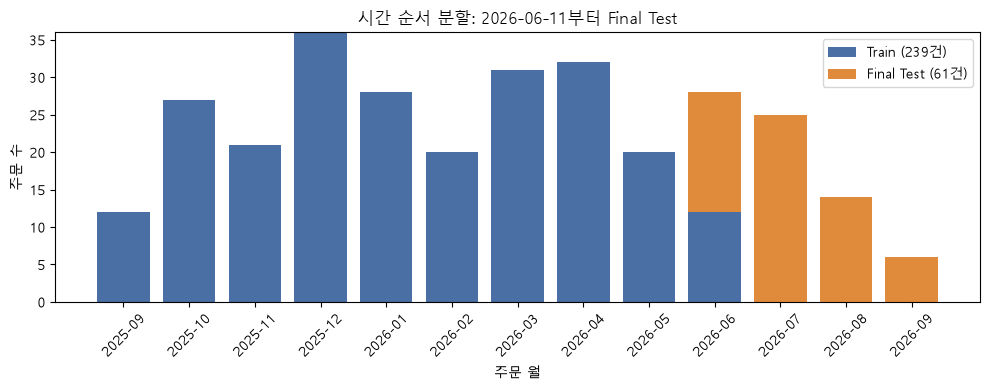

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트 (Windows)
plt.rcParams['axes.unicode_minus'] = False

# 0) 경로 설정
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name in ['notebooks', 'chapter09'] else CURRENT_DIR
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
REPORT_DIR = PROJECT_ROOT / 'reports'
IMAGE_DIR = PROJECT_ROOT / 'chapter09' / 'images'
REPORT_DIR.mkdir(exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# 1) 데이터 불러오기 + 주문별 Target(order_total) 만들기
orders = pd.read_csv(RAW_DIR / 'orders.csv', encoding='utf-8-sig')
order_items = pd.read_csv(RAW_DIR / 'order_items.csv', encoding='utf-8-sig')
order_items['line_total'] = order_items['quantity'] * order_items['unit_price']
target = order_items.groupby('order_id', as_index=False)['line_total'].sum()
target = target.rename(columns={'line_total': 'order_total'})

# 2) 주문 날짜 붙이고 날짜순 정렬
data = target.merge(orders[['order_id', 'order_date']], on='order_id', how='inner')
data['order_date'] = pd.to_datetime(data['order_date'])
data = data.sort_values('order_date').reset_index(drop=True)
print('전체 주문 수:', len(data))

# 3) 기준 날짜 정하기: 앞쪽 80% = Train(과거), 뒤쪽 20% = Final Test(최근)
cut_index = int(len(data) * 0.8)
cut_date = data.loc[cut_index, 'order_date']    # 이 날짜부터 Final Test
train_data = data[data['order_date'] < cut_date]
test_data = data[data['order_date'] >= cut_date]
print('기준 날짜(이 날부터 Test):', cut_date.date())

# 4) 같은 날짜가 양쪽에 있는지 확인
overlap = set(train_data['order_date']) & set(test_data['order_date'])

# 5) Split Summary 표 만들기 + 저장
split_summary = pd.DataFrame({
    '구분': ['Train', 'Final Test'],
    '시작일': [train_data['order_date'].min().date(), test_data['order_date'].min().date()],
    '종료일': [train_data['order_date'].max().date(), test_data['order_date'].max().date()],
    '행 수': [len(train_data), len(test_data)],
    '같은 날짜 overlap': [len(overlap), len(overlap)],
})
display(split_summary)
split_summary.to_csv(REPORT_DIR / 'ch09_regression_split_summary.csv', index=False, encoding='utf-8-sig')

# 6) 핵심 조건 확인 (틀리면 여기서 멈춤)
assert train_data['order_date'].max() < test_data['order_date'].min(), 'Train과 Test 날짜가 겹칩니다!'
assert len(overlap) == 0, '같은 날짜가 양쪽에 있습니다!'
print('Train 최대 날짜 < Final Test 최소 날짜: PASS')
print('같은 날짜 overlap 0건: PASS')

# 7) Evidence 이미지: 월별 주문 수를 Train / Final Test 색으로 구분
data['월'] = data['order_date'].dt.strftime('%Y-%m')
data['구분'] = 'Train'
data.loc[data['order_date'] >= cut_date, '구분'] = 'Final Test'
monthly = pd.crosstab(data['월'], data['구분']).reindex(columns=['Train', 'Final Test'], fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly.index, monthly['Train'], color='#4a6fa5', label=f'Train ({len(train_data)}건)')
ax.bar(monthly.index, monthly['Final Test'], bottom=monthly['Train'], color='#e08a3c',
       label=f'Final Test ({len(test_data)}건)')
ax.set_title(f'시간 순서 분할: {cut_date.date()}부터 Final Test')
ax.set_xlabel('주문 월')
ax.set_ylabel('주문 수')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'step04_split.png', dpi=150)
plt.show()



### STEP 4 결과 요약

| 구분 | 시작일 | 종료일 | 행 수 |
|---|---|---|---|
| Train | 2025-09-11 | 2026-06-10 | 239 (80%) |
| Final Test | 2026-06-11 | 2026-09-10 | 61 (20%) |

- Train 최대 날짜(2026-06-10) < Final Test 최소 날짜(2026-06-11) → **PASS**
- 같은 날짜 overlap **0건** → **PASS**
- Evidence: `reports/ch09_regression_split_summary.csv`, `chapter09/images/step04_split.png`

### 왜 랜덤 분할이 아니라 시간 순서 분할인가?
- 실제로 모델을 쓸 때는 **과거 주문으로 학습해서 미래 주문을 예측**한다.
- 랜덤으로 나누면 미래 주문이 Train에 섞여 **시험 문제를 미리 보고 공부하는 셈**이 되고, 점수가 실제보다 좋게 나온다.
- 시간 순서로 나누면 처음 보는 미래 기간으로 평가하므로 **실제 사용 상황과 같은 조건**에서 성능을 확인할 수 있다.

### 참고
- Train에는 7월과 8월 주문이 없다. 그래서 `order_month_num`의 7과 8은 학습 때 한 번도 보지 못한 값이고, 월에 따른 예측은 약할 수 있다.

In [5]:
import pandas as pd
from pathlib import Path

# 0) 경로 설정
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name in ['notebooks', 'chapter09'] else CURRENT_DIR
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'

# 1) 데이터 불러오기
orders = pd.read_csv(RAW_DIR / 'orders.csv', encoding='utf-8-sig')
order_items = pd.read_csv(RAW_DIR / 'order_items.csv', encoding='utf-8-sig')
customers = pd.read_csv(RAW_DIR / 'customers.csv', encoding='utf-8-sig')

# 2) Target(order_total) 만들기
order_items['line_total'] = order_items['quantity'] * order_items['unit_price']
target = order_items.groupby('order_id', as_index=False)['line_total'].sum()
target = target.rename(columns={'line_total': 'order_total'})

# 3) 주문 + 고객 + Target 합치기 (관계는 STEP 3에서 검증 완료)
data = orders.merge(customers[['customer_id', 'gender', 'age', 'city']], on='customer_id', how='left')
data = data.merge(target, on='order_id', how='left')

# 4) 주문 시점에 알 수 있는 feature 만들기
data['order_date'] = pd.to_datetime(data['order_date'])
data['order_month_num'] = data['order_date'].dt.month       # 월 숫자 (1~12)
data['order_dayofweek'] = data['order_date'].dt.dayofweek   # 요일 (0=월 ~ 6=일)

# 5) 날짜순 정렬 후 STEP 4와 같은 기준으로 분리 (앞 80% = Train, 뒤 20% = Final Test)
data = data.sort_values('order_date').reset_index(drop=True)
cut_date = data.loc[int(len(data) * 0.8), 'order_date']
train_data = data[data['order_date'] < cut_date]
test_data = data[data['order_date'] >= cut_date]

# 6) 숫자형 / 범주형 feature 구분
numeric_features = ['order_month_num', 'order_dayofweek', 'age']
categorical_features = ['payment_method', 'gender', 'city']
feature_columns = numeric_features + categorical_features

X_train = train_data[feature_columns].copy()
X_test = test_data[feature_columns].copy()
y_train = train_data['order_total'].copy()
y_test = test_data['order_total'].copy()

print('Train:', X_train.shape, '| Final Test:', X_test.shape)
print('기준 날짜:', cut_date.date())

# 7) 아직 전처리하지 않은 원본 상태 확인
print('\n[숫자형] 결측치 개수 (Train / Test)')
print(pd.DataFrame({'Train': X_train[numeric_features].isna().sum(),
                    'Test': X_test[numeric_features].isna().sum()}))
print('\n[범주형] 결측치 개수 (Train / Test)')
print(pd.DataFrame({'Train': X_train[categorical_features].isna().sum(),
                    'Test': X_test[categorical_features].isna().sum()}))

print('\n[숫자형] Train 요약 (전처리 전)')
display(X_train[numeric_features].describe().round(2))

print('[범주형] Train 값 종류 수')
print(X_train[categorical_features].nunique())
print('\nTest에만 있는 범주 (Train에 없음):')
for col in categorical_features:
    only_test = set(X_test[col].dropna()) - set(X_train[col].dropna())
    print(' ', col, '->', sorted(only_test))

Train: (239, 6) | Final Test: (61, 6)
기준 날짜: 2026-06-11

[숫자형] 결측치 개수 (Train / Test)
                 Train  Test
order_month_num      0     0
order_dayofweek      0     0
age                  0     0

[범주형] 결측치 개수 (Train / Test)
                Train  Test
payment_method      0     0
gender              0     0
city                0     0

[숫자형] Train 요약 (전처리 전)


,order_month_num,order_dayofweek,age
count,239.00,239.00,239.00
mean,6.28,3.03,41.09
std,3.99,2.07,15.73
min,1.00,0.00,19.00
25%,3.00,1.00,28.00
50%,5.00,3.00,36.00
75%,10.00,5.00,58.00
max,12.00,6.00,69.00


[범주형] Train 값 종류 수
payment_method     4
gender             2
city              10
dtype: int64

Test에만 있는 범주 (Train에 없음):
  payment_method -> []
  gender -> []
  city -> []


In [6]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# (앞 셀에서 만든 X_train, X_test, numeric_features를 그대로 사용합니다)

# 1) 결측치 대체기: Train의 median을 기억(fit)
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train[numeric_features])                      # Train으로만 fit
print('Train median:', dict(zip(numeric_features, imputer.statistics_)))

# 2) Train과 Test에 적용 (transform만)
train_imputed = imputer.transform(X_train[numeric_features])
test_imputed = imputer.transform(X_test[numeric_features])

# 3) 표준화: Train의 평균과 표준편차를 기억(fit)
scaler = StandardScaler()
scaler.fit(train_imputed)                                    # Train으로만 fit
print('Train 평균:', dict(zip(numeric_features, scaler.mean_.round(2))))
print('Train 표준편차:', dict(zip(numeric_features, scaler.scale_.round(2))))

# 4) Train과 Test에 적용 (transform만)
X_train_num = pd.DataFrame(scaler.transform(train_imputed), columns=numeric_features, index=X_train.index)
X_test_num = pd.DataFrame(scaler.transform(test_imputed), columns=numeric_features, index=X_test.index)

# 5) 결과 확인
print('\n[Train 변환 후] 평균은 0, 표준편차는 1에 가까워야 함')
print(X_train_num.agg(['mean', 'std']).round(2))
print('\n[Final Test 변환 후] 0, 1과 정확히 같지 않아도 정상 (Train 기준으로 맞췄기 때문)')
print(X_test_num.agg(['mean', 'std']).round(2))

print('\n변환 전 Train 앞 3행')
print(X_train[numeric_features].head(3))
print('변환 후 Train 앞 3행')
print(X_train_num.head(3).round(2))

Train median: {'order_month_num': np.float64(5.0), 'order_dayofweek': np.float64(3.0), 'age': np.float64(36.0)}
Train 평균: {'order_month_num': np.float64(6.28), 'order_dayofweek': np.float64(3.03), 'age': np.float64(41.09)}
Train 표준편차: {'order_month_num': np.float64(3.98), 'order_dayofweek': np.float64(2.07), 'age': np.float64(15.69)}

[Train 변환 후] 평균은 0, 표준편차는 1에 가까워야 함
      order_month_num  order_dayofweek  age
mean             -0.0             -0.0 -0.0
std               1.0              1.0  1.0

[Final Test 변환 후] 0, 1과 정확히 같지 않아도 정상 (Train 기준으로 맞췄기 때문)
      order_month_num  order_dayofweek   age
mean             0.22            -0.19  0.10
std              0.23             0.92  0.95

변환 전 Train 앞 3행
   order_month_num  order_dayofweek  age
0                9                3   67
1                9                5   63
2                9                6   69
변환 후 Train 앞 3행
   order_month_num  order_dayofweek   age
0             0.68            -0.01  1.65
1             0.68  

## STEP 5. 전처리는 Pipeline 내부에서 수행 (전처리 누수 방지)

### 진행 순서 (수동으로 한 단계씩 확인)
| 단계 | 내용 | 결과 |
|---|---|---|
| 1단계 | feature 6개 표 만들기, 시간 순서로 Train/Test 분리, 결측치 확인 | Train 239행, Test 61행, 결측치 0개 |
| 2단계 | 숫자형: median 대체 → StandardScaler | Train 평균 0, 표준편차 1 |
| 3단계 | 범주형: most_frequent 대체 → OneHotEncoder | 컬럼 3개 → 16개 |
| 4단계 | 위 과정을 Pipeline으로 묶고 수동 결과와 비교 | (진행 예정) |

### 전처리 누수 방지
- **숫자형 처리**: `order_month_num`, `order_dayofweek`, `age` → 결측치는 median으로 대체 → StandardScaler로 표준화
- **범주형 처리**: `payment_method`, `gender`, `city` → 결측치는 most_frequent로 대체 → OneHotEncoder(`handle_unknown="ignore"`)
- **전처리 fit 범위**: **Train에만 fit**한다. Final Test에는 **transform만** 적용한다. (교차검증에서는 각 Train Fold에만 fit)
- **전체 데이터에 먼저 fit하면 안 되는 이유**: Test의 평균, median, 범주 정보가 전처리에 섞여 들어가 **시험 문제를 미리 보는 것과 같은 누수**가 생기고, 점수가 실제보다 좋게 나온다.

### 확인한 결과
- 결측치는 Train과 Test 모두 0개라 대체값이 실제로 쓰이지는 않았다. 새 데이터에 결측이 생길 때를 대비해 Pipeline에는 그대로 넣는다.
- Train 기준 median: 월 5, 요일 3, 나이 36
- Final Test를 변환하면 평균이 0이 아닌 값(월 0.22, 요일 -0.19, 나이 0.10)으로 나온다. **정상이다.** Train의 평균과 표준편차를 그대로 적용했기 때문이다.
- OneHotEncoder 결과는 Train과 Test 모두 16개 컬럼이고, 각 행에서 1이 3개다. 숫자형 3개와 합치면 **최종 19개 컬럼**이다.
- Test에만 있는 범주는 없었다.

### 결론
- 전처리는 모두 Train에서만 학습했고, Test에는 적용만 했다.
- 이후 교차검증과 최종 평가는 이 과정을 **Pipeline으로 묶어서** 진행한다. Fold마다 전처리를 다시 fit해야 하는데, 수동으로는 실수하기 쉽기 때문이다.

STEP 6. Baseline과 후보 모델을 준비합니다

STEP 7. Train 기간에서 TimeSeriesSplit으로 후보를 비교합니다

In [7]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# (앞 셀에서 만든 PROJECT_ROOT, X_train, X_test, y_train, numeric_features, categorical_features,
#  X_train_num, X_test_num 을 그대로 사용합니다)

# ============ STEP 6. Baseline과 후보 모델 준비 ============
# 1) 전처리 묶음: 숫자형 / 범주형을 각각 처리
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])

# 2) 후보 모델 3개: 각각 '전처리 + 모델'을 하나의 Pipeline으로 묶기
models = {
    'Baseline Mean': Pipeline([('prep', preprocessor), ('model', DummyRegressor(strategy='mean'))]),
    'Linear Regression': Pipeline([('prep', preprocessor), ('model', LinearRegression())]),
    'Random Forest': Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42))]),
}

print('후보 모델:', list(models))
for name, pipe in models.items():
    print(f'- {name}:', [step_name for step_name, _ in pipe.steps], '->', type(pipe.named_steps['model']).__name__)

# 3) STEP 5 확인: Pipeline의 숫자형 전처리 결과가 수동 결과(2단계)와 같은지 비교
prep_check = Pipeline([('prep', preprocessor)])
train_by_pipeline = prep_check.fit_transform(X_train)        # Train으로만 fit
test_by_pipeline = prep_check.transform(X_test)              # Test는 transform만
train_by_pipeline = train_by_pipeline.toarray() if hasattr(train_by_pipeline, 'toarray') else train_by_pipeline
test_by_pipeline = test_by_pipeline.toarray() if hasattr(test_by_pipeline, 'toarray') else test_by_pipeline

n_num = len(numeric_features)   # 숫자형 컬럼은 결과의 맨 앞 3개
print('\nPipeline 전처리 결과:', train_by_pipeline.shape, test_by_pipeline.shape)
print('숫자형 3개 - 수동 결과와 Train 동일:', np.allclose(train_by_pipeline[:, :n_num], X_train_num.values))
print('숫자형 3개 - 수동 결과와 Final Test 동일:', np.allclose(test_by_pipeline[:, :n_num], X_test_num.values))

# ============ STEP 7. Train 기간에서 TimeSeriesSplit으로 후보 비교 ============
# (Final Test는 사용하지 않고, X_train / y_train만 사용합니다)
REPORT_DIR = PROJECT_ROOT / 'reports'
REPORT_DIR.mkdir(exist_ok=True)

# 4) 시간 순서 교차검증: 과거로 공부하고 그 다음 기간으로 검증 (X_train은 날짜순 정렬 상태)
tscv = TimeSeriesSplit(n_splits=5)
print()
for i, (tr_idx, va_idx) in enumerate(tscv.split(X_train), start=1):
    print(f'Fold {i}: 공부 {len(tr_idx)}건 -> 검증 {len(va_idx)}건')

# 5) 후보 3개를 같은 방식으로 평가
rows = []
for name, pipe in models.items():
    cv = cross_validate(
        pipe, X_train, y_train, cv=tscv,
        scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
    )
    mae = -cv['test_mae']    # 부호를 바꿔 오차(MAE)로 표시
    rows.append({
        '모델': name,
        'cv_MAE_mean': round(mae.mean(), 0),
        'cv_MAE_std': round(mae.std(), 0),
        'cv_R2_mean': round(cv['test_r2'].mean(), 3),
        'fold별 MAE': [int(v) for v in mae],
    })
cv_summary = pd.DataFrame(rows)

# 6) 비고 추가: Baseline보다 나은지 표시
baseline_mae = cv_summary.loc[cv_summary['모델'] == 'Baseline Mean', 'cv_MAE_mean'].iloc[0]
def make_note(row):
    if row['모델'] == 'Baseline Mean':
        return '기준점'
    return 'Baseline보다 낮음(좋음)' if row['cv_MAE_mean'] < baseline_mae else 'Baseline보다 높음(나쁨)'
cv_summary['비고'] = cv_summary.apply(make_note, axis=1)
display(cv_summary)

# 7) Evidence 저장
cv_summary.to_csv(REPORT_DIR / 'ch09_regression_cv_summary.csv', index=False, encoding='utf-8-sig')


# 8) 비베이스라인 두 모델 중 CV MAE 평균이 더 낮은 모델 선택
candidates = cv_summary[cv_summary['모델'].isin(['Linear Regression', 'Random Forest'])]
selected_model_name = candidates.sort_values('cv_MAE_mean').iloc[0]['모델']
print('\n선택된 모델(Train CV MAE 평균이 더 낮음):', selected_model_name)
print('※ 여기까지 Final Test 성능은 보지 않았습니다.')

후보 모델: ['Baseline Mean', 'Linear Regression', 'Random Forest']
- Baseline Mean: ['prep', 'model'] -> DummyRegressor
- Linear Regression: ['prep', 'model'] -> LinearRegression
- Random Forest: ['prep', 'model'] -> RandomForestRegressor

Pipeline 전처리 결과: (239, 19) (61, 19)
숫자형 3개 - 수동 결과와 Train 동일: True
숫자형 3개 - 수동 결과와 Final Test 동일: True

Fold 1: 공부 44건 -> 검증 39건
Fold 2: 공부 83건 -> 검증 39건
Fold 3: 공부 122건 -> 검증 39건
Fold 4: 공부 161건 -> 검증 39건
Fold 5: 공부 200건 -> 검증 39건


,모델,cv_MAE_mean,cv_MAE_std,cv_R2_mean,fold별 MAE,비고
0,Baseline Mean,420959.0,45361.0,-0.026,"[475350, 366562, 369131, 459942, 433805]",기준점
1,Linear Regression,470981.0,74273.0,-0.384,"[615229, 460576, 404880, 436056, 438160]",Baseline보다 높음(나쁨)
2,Random Forest,469067.0,53894.0,-0.349,"[571296, 447188, 428640, 425000, 473210]",Baseline보다 높음(나쁨)



선택된 모델(Train CV MAE 평균이 더 낮음): Random Forest
※ 여기까지 Final Test 성능은 보지 않았습니다.


## STEP 6~7. 후보 모델 준비와 TimeSeriesSplit 비교

### STEP 6. 후보 모델 (전처리 + 모델을 Pipeline으로 묶음)
| 모델 | 역할 |
|---|---|
| Baseline Mean (`DummyRegressor`) | 항상 평균만 예측하는 기준점 |
| Linear Regression | 단순한 후보 |
| Random Forest | 복잡한 후보 (`random_state=42`) |

- Baseline은 성능이 낮은 모델이 아니라, **복잡한 모델이 추가 가치를 만드는지 판단하는 기준점**이다.
- 세 모델 모두 `전처리 → 모델` 두 단계 Pipeline이고, 전처리는 Train 또는 각 Train Fold에서만 fit된다.
- Pipeline의 숫자형 전처리 결과는 수동으로 한 결과(STEP 5 2단계)와 Train, Final Test 모두 같았다.
- 범주형 전처리는 Pipeline 안에서 처리했고 수동 확인은 생략했다.

**Random Forest가 복잡하니까 평균 예측보다 우수하다고 말할 수 있는가?**
→ 아니오. 실제 검증 결과가 필요하다. (STEP 7 결과가 이를 보여 준다.)

### STEP 7. Train 기간 TimeSeriesSplit 교차검증 (5 Fold, Final Test는 사용하지 않음)
| 모델 | CV MAE 평균 | CV MAE 표준편차 | CV R² 평균 | 비고 |
|---|---|---|---|---|
| Baseline Mean | 420,959 | 45,361 | -0.026 | 기준점 |
| Linear Regression | 470,981 | 74,273 | -0.384 | Baseline보다 나쁨 |
| Random Forest | 469,067 | 53,894 | -0.349 | Baseline보다 나쁨 |

- Evidence: `reports/ch09_regression_cv_summary.csv`
- **선택된 모델: Random Forest** (비베이스라인 두 모델 중 CV MAE 평균이 더 낮음)

### 해석
- **두 모델 모두 Baseline보다 오차가 크고, R²도 음수다.** 현재 feature로는 평균 예측을 이기지 못했다.
- Random Forest와 Linear Regression의 MAE 차이(약 2,000)는 표준편차(약 5만~7만)보다 훨씬 작아서 **사실상 차이가 없다.** 선택은 규칙에 따른 것이지 확실한 우열은 아니다.
- Linear Regression은 Fold마다 MAE가 404,880~615,229로 크게 흔들려 **결과가 불안정**하다.
- 원인은 사용한 feature(월, 요일, 결제수단, 나이, 성별, 도시)가 주문 금액과 거의 관계가 없기 때문으로 보인다. 금액을 결정하는 수량과 단가는 누수 방지를 위해 제외했다.

### 결론
- 낮은 성능과 음수 R²도 숨기지 않고 그대로 기록한다.
- Final Test는 아직 보지 않았고, 선택된 모델은 Final Test 전에 고정했다.
- 현재 데이터와 feature로는 **"모델 사용 보류"도 올바른 결론**이 될 수 있다. STEP 9 Final Test에서 Baseline과 다시 비교해 최종 판단한다.

### 평가지표 정의
| 지표 | 뜻 | 읽는 법 |
|---|---|---|
| **MAE** (평균 절대 오차) | 예측값과 실제값의 차이(절대값)를 평균한 값 | **작을수록 좋다.** 예: 469,067이면 평균적으로 약 47만 정도 틀린다는 뜻 |
| **CV MAE 평균** | Fold 5번의 MAE를 평균한 값 | 모델의 평균적인 오차 수준 |
| **CV MAE 표준편차** | Fold마다 MAE가 얼마나 흔들리는지 | **작을수록 안정적이다.** 평균이 좋아도 이 값이 크면 결과를 믿기 어렵다 |
| **R²** (결정계수) | 모델이 "평균 예측"보다 얼마나 잘 맞히는가 | 1에 가까울수록 좋고, **0이면 평균 예측과 같고, 음수면 평균 예측보다 나쁘다** |

- **CV**(교차검증)는 Train 기간을 시간 순서로 5번 나눠서 "과거로 공부하고 바로 다음 기간으로 시험"을 반복한 것이다.
- **Baseline 비교가 핵심이다.** MAE는 Baseline보다 낮아야 하고, R²는 0보다 커야 복잡한 모델이 추가 가치를 만든다고 말할 수 있다.
- 이번 결과에서 두 모델의 R²는 -0.384와 -0.349로, 평균 예측보다 나쁘다는 뜻이다.


## STEP 7 결과 해석: 세 모델 성능 비교

### 한눈에 보기
| 모델 | CV MAE 평균 | CV MAE 표준편차 | CV R² 평균 | 종합 |
|---|---|---|---|---|
| Baseline Mean | 약 42.1만 | 약 4.5만 | -0.026 | **가장 좋음** |
| Random Forest | 약 46.9만 | 약 5.4만 | -0.349 | Baseline보다 나쁨 |
| Linear Regression | 약 47.1만 | 약 7.4만 | -0.384 | Baseline보다 나쁨, 가장 불안정 |

**결론: 평균만 예측하는 Baseline을 이기는 모델이 없다.**

### 1. MAE (평균 오차, 작을수록 좋음)
- Baseline은 평균적으로 약 42만 틀린다. Random Forest와 Linear Regression은 각각 약 47만 틀린다.
- Baseline과의 차이는 Random Forest가 **+4.8만(약 11% 더 틀림)**, Linear Regression이 **+5.0만(약 12% 더 틀림)**이다.
- 두 모델 사이의 차이는 약 1,900으로 거의 없다. 표준편차(5만~7만)에 비하면 **사실상 같은 수준**이다.
- 그래서 선택 규칙에 따라 Random Forest가 뽑혔지만, 이는 "확실히 더 좋다"가 아니라 **규칙상 근소하게 앞선 것**이다.

### 2. MAE 표준편차 (흔들림, 작을수록 안정적)
| 모델 | 표준편차 | 평균 대비 흔들림 | Fold 중 최소~최대 MAE |
|---|---|---|---|
| Baseline Mean | 4.5만 | 10.8% | 36.7만 ~ 47.5만 |
| Random Forest | 5.4만 | 11.5% | 42.5만 ~ 57.1만 |
| Linear Regression | 7.4만 | 15.8% | 40.5만 ~ 61.5만 |

- Baseline이 가장 안정적이고, Linear Regression이 가장 불안정하다.
- Linear Regression은 Fold에 따라 최소와 최대가 약 21만이나 벌어져서, 어떤 기간에 쓰느냐에 따라 결과가 크게 달라진다.

### 3. R² (평균 예측보다 나은 정도, 0보다 커야 의미 있음)
- Baseline의 R²는 거의 0(-0.026)이다. 평균을 예측하는 모델이니 0 근처인 것이 정상이다.
- Random Forest(-0.349)와 Linear Regression(-0.384)은 **음수**이다. 평균 예측보다 못하다는 뜻이다.
- 세 모델 모두 R²가 0을 넘지 못해서, 이 feature들로 금액 변동을 설명하지 못한다.

### 4. Fold별 비교 (각 Fold에서 Baseline과의 MAE 차이, +는 Baseline보다 더 틀림)
| Fold | 공부한 건수 | Baseline MAE | Linear Regression | Random Forest |
|---|---|---|---|---|
| 1 | 44 | 475,350 | 615,229 (+139,879) | 571,296 (+95,946) |
| 2 | 83 | 366,562 | 460,576 (+94,014) | 447,188 (+80,626) |
| 3 | 122 | 369,131 | 404,880 (+35,749) | 428,640 (+59,509) |
| 4 | 161 | 459,942 | 436,056 (-23,886) | 425,000 (-34,942) |
| 5 | 200 | 433,805 | 438,160 (+4,355) | 473,210 (+39,405) |

- **Baseline을 이긴 Fold는 5번 중 Fold 4 하나뿐**이다. 두 모델 모두 나머지 4번은 졌다.
- **공부한 건수가 적을수록 차이가 크다.** Fold 1(44건)에서는 두 모델이 Baseline보다 10만~14만 더 틀렸다. 데이터가 적으면 복잡한 모델이 잡음까지 외워서 오히려 나빠진다.
- Linear Regression은 Fold 1에서 5까지 차이가 +14만 → +9만 → +3.6만 → -2.4만 → +0.4만으로 **줄어드는 경향**이 있다. 데이터가 늘수록 Baseline에 가까워진다는 뜻이다.
- Random Forest는 Fold 4를 빼면 계속 4만~10만 더 틀려서 그런 경향이 뚜렷하지 않다.
- Fold가 5개뿐이라 이 경향을 확실한 사실로 단정할 수는 없다.

### 5. 두 모델 직접 비교
| 항목 | Linear Regression | Random Forest | 우세 |
|---|---|---|---|
| CV MAE 평균 | 470,981 | 469,067 | Random Forest (차이 미미) |
| 안정성(표준편차) | 74,273 | 53,894 | Random Forest |
| CV R² | -0.384 | -0.349 | Random Forest (차이 미미) |
| Fold별 승수 (MAE가 낮은 횟수) | 2번 | 3번 | Random Forest (근소) |

- Random Forest가 모든 지표에서 근소하게 앞서지만 **안정성 외에는 의미 있는 차이가 아니다.**
- 두 모델 모두 Baseline보다 나쁘므로, 둘 중 무엇을 고르든 결론은 달라지지 않는다.

### 6. 왜 이런 결과가 나왔나
- 사용한 feature(주문 월, 요일, 결제수단, 나이, 성별, 도시)는 주문 금액과 관계가 약하다. (상관계수 -0.03~0.05 수준)
- 주문 금액은 수량과 단가로 결정되는데, 예측 시점에 알 수 없어서 누수 방지를 위해 **제외했다.**
- 관계가 없는 feature를 복잡한 모델에 넣으면, 우연한 패턴을 외워서 오히려 성능이 나빠진다.
- 이 결과는 오류가 아니라 **누수를 막았을 때 나오는 정직한 결과**이다.

### 7. 결론과 다음 단계
- Train 교차검증 기준으로 **Random Forest와 Linear Regression 모두 Baseline을 이기지 못했다.**
- 선택된 모델은 Random Forest이며, 이 선택은 **Final Test 전에 고정**한다. Final Test 결과를 보고 바꾸지 않는다.
- STEP 9의 Final Test에서 Baseline과 다시 비교한다. 여기서도 Baseline을 이기지 못하면 **"현재 데이터로는 모델 사용 보류"**가 최종 결론이다.

STEP 7. Train 기간에서 TimeSeriesSplit으로 후보를 비교합니다

In [8]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, cross_validate

# (앞 셀에서 만든 PROJECT_ROOT, models, X_train, y_train을 그대로 사용합니다)
# ※ Final Test(X_test, y_test)는 이 셀에서 사용하지 않습니다.

REPORT_DIR = PROJECT_ROOT / 'reports'
REPORT_DIR.mkdir(exist_ok=True)

# 1) 시간 순서 교차검증 설정: 과거로 공부하고 바로 다음 기간으로 시험 (X_train은 날짜순 정렬 상태)
tscv = TimeSeriesSplit(n_splits=5)
for i, (tr_idx, va_idx) in enumerate(tscv.split(X_train), start=1):
    print(f'Fold {i}: 공부 {len(tr_idx)}건 -> 검증 {len(va_idx)}건')

# 2) 후보 3개를 같은 방식으로 평가
rows = []
fold_mae = {}
for name, pipe in models.items():
    cv = cross_validate(
        pipe, X_train, y_train, cv=tscv,
        scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
    )
    mae = -cv['test_mae']                     # 부호를 바꿔 오차(MAE)로 표시
    fold_mae[name] = mae
    rows.append({
        '모델': name,
        'cv_MAE_mean': round(mae.mean(), 0),
        'cv_MAE_std': round(mae.std(), 0),
        'cv_R2_mean': round(cv['test_r2'].mean(), 3),
    })
cv_summary = pd.DataFrame(rows)

# 3) 비고: Baseline보다 나은지 표시
baseline_mae = cv_summary.loc[cv_summary['모델'] == 'Baseline Mean', 'cv_MAE_mean'].iloc[0]
def make_note(row):
    if row['모델'] == 'Baseline Mean':
        return '기준점'
    return 'Baseline보다 낮음(좋음)' if row['cv_MAE_mean'] < baseline_mae else 'Baseline보다 높음(나쁨)'
cv_summary['비고'] = cv_summary.apply(make_note, axis=1)
print('\n[CV 요약]')
display(cv_summary)

# 4) Fold별 MAE (평균은 좋아 보이는데 Fold마다 크게 흔들리는지 확인)
fold_table = pd.DataFrame(fold_mae, index=[f'Fold {i}' for i in range(1, 6)]).round(0).astype(int)
fold_table['Linear - Baseline'] = fold_table['Linear Regression'] - fold_table['Baseline Mean']
fold_table['RandomForest - Baseline'] = fold_table['Random Forest'] - fold_table['Baseline Mean']
print('[Fold별 MAE] (마지막 두 열이 +이면 Baseline보다 더 틀림)')
display(fold_table)

# 5) Evidence 저장
cv_summary.to_csv(REPORT_DIR / 'ch09_regression_cv_summary.csv', index=False, encoding='utf-8-sig')


# 6) 비베이스라인 두 모델 중 CV MAE 평균이 더 낮은 모델 선택
candidates = cv_summary[cv_summary['모델'].isin(['Linear Regression', 'Random Forest'])]
selected_model_name = candidates.sort_values('cv_MAE_mean').iloc[0]['모델']
print('\n선택된 모델(Train CV MAE 평균이 더 낮음):', selected_model_name)
print('※ 여기까지 Final Test 성능은 보지 않았습니다.')

Fold 1: 공부 44건 -> 검증 39건
Fold 2: 공부 83건 -> 검증 39건
Fold 3: 공부 122건 -> 검증 39건
Fold 4: 공부 161건 -> 검증 39건
Fold 5: 공부 200건 -> 검증 39건

[CV 요약]


,모델,cv_MAE_mean,cv_MAE_std,cv_R2_mean,비고
0,Baseline Mean,420959.0,45361.0,-0.026,기준점
1,Linear Regression,470981.0,74273.0,-0.384,Baseline보다 높음(나쁨)
2,Random Forest,469067.0,53894.0,-0.349,Baseline보다 높음(나쁨)


[Fold별 MAE] (마지막 두 열이 +이면 Baseline보다 더 틀림)


,Baseline Mean,Linear Regression,Random Forest,Linear - Baseline,RandomForest - Baseline
Fold 1,475351,615230,571297,139879,95946
Fold 2,366562,460576,447189,94014,80627
Fold 3,369132,404881,428640,35749,59508
Fold 4,459943,436057,425000,-23886,-34943
Fold 5,433805,438161,473211,4356,39406



선택된 모델(Train CV MAE 평균이 더 낮음): Random Forest
※ 여기까지 Final Test 성능은 보지 않았습니다.


## STEP 7 결과 해석과 결론

### 실행 결과
**CV 요약 (Train 기간, TimeSeriesSplit 5 Fold)**

| 모델 | CV MAE 평균 | CV MAE 표준편차 | CV R² 평균 | 비고 |
|---|---|---|---|---|
| Baseline Mean | 420,959 | 45,361 | -0.026 | 기준점 |
| Linear Regression | 470,981 | 74,273 | -0.384 | Baseline보다 높음(나쁨) |
| Random Forest | 469,067 | 53,894 | -0.349 | Baseline보다 높음(나쁨) |

**Fold별 MAE** (차이가 +이면 Baseline보다 더 틀림)

| Fold | Baseline | Linear Regression | Random Forest | Linear - Baseline | RF - Baseline |
|---|---|---|---|---|---|
| Fold 1 | 475,351 | 615,230 | 571,297 | +139,879 | +95,946 |
| Fold 2 | 366,562 | 460,576 | 447,189 | +94,014 | +80,627 |
| Fold 3 | 369,132 | 404,881 | 428,640 | +35,749 | +59,508 |
| Fold 4 | 459,943 | 436,057 | 425,000 | -23,886 | -34,943 |
| Fold 5 | 433,805 | 438,161 | 473,211 | +4,356 | +39,406 |

### 해석
1. **평균 오차(MAE)**: Baseline이 가장 낮다. Random Forest는 약 11%, Linear Regression은 약 12% 더 틀린다. 두 모델은 서로 거의 같다(차이 약 1,900).
2. **안정성(표준편차)**: Baseline(4.5만)이 가장 안정적이고, Random Forest(5.4만), Linear Regression(7.4만) 순이다. Linear Regression은 Fold에 따라 40만에서 61만까지 크게 흔들린다.
3. **설명력(R²)**: 두 모델 모두 음수이다. 평균만 예측하는 것보다 못하다는 뜻이다.
4. **Fold별**: 두 모델이 Baseline을 이긴 Fold는 5번 중 **Fold 4 하나뿐**이다. 나머지 4번은 모두 더 틀렸다.
5. **데이터가 적을수록 더 나쁘다**: Fold 1(공부 44건)에서 두 모델은 Baseline보다 약 10만~14만 더 틀렸다. Linear Regression은 Fold가 갈수록 차이가 줄어드는 경향(+14만 → +9만 → +3.6만 → -2.4만 → +0.4만)이 있다. 다만 5개 Fold로 본 관찰이라 단정하지는 않는다.

### 질문에 대한 답
- **평균은 좋아 보이지만 Fold마다 크게 흔들리는가?**
  → 두 모델은 평균 자체가 Baseline보다 나쁘고, Linear Regression은 특히 크게 흔들린다(표준편차 7.4만). 평균도 나쁘고 안정성도 떨어진다.

### 모델 선택
- 규칙(Train CV MAE 평균이 더 낮은 비베이스라인 모델)에 따라 **Random Forest를 선택**한다.
- 다만 Linear Regression과의 차이가 표준편차보다 훨씬 작아서 **확실한 우열이 아니라 규칙상 근소한 차이**이다.
- 이 선택은 **Final Test를 보기 전에 고정**한다. Final Test 결과를 보고 다른 모델로 바꾸지 않는다.

### 결론
- Train 교차검증 기준으로 **복잡한 모델(Random Forest, Linear Regression)은 Baseline(평균 예측)보다 나은 점이 없었다.**
- 이유는 사용한 feature(월, 요일, 결제수단, 나이, 성별, 도시)가 주문 금액과 거의 관계가 없기 때문이다. 금액을 결정하는 수량과 단가는 누수 방지를 위해 제외했다.
- 성능이 낮은 결과도 숨기지 않고 그대로 기록한다. 누수를 막았을 때 나오는 정직한 결과이다.
- STEP 9의 Final Test에서 Baseline과 다시 비교하고, 여기서도 이기지 못하면 **"현재 데이터로는 모델 사용 보류"**를 최종 결론으로 한다.
- Evidence: `reports/ch09_regression_cv_summary.csv`

In [9]:
### STEP 8. Selected Model을 Final Test 전에 고정합니다

import pandas as pd

# (앞 STEP 7 셀에서 만든 cv_summary, models를 그대로 사용합니다)
# ※ 이 셀에서도 Final Test(X_test, y_test)는 사용하지 않습니다.

# 1) Train CV 결과 확인
print('[Train CV 결과]')
display(cv_summary[['모델', 'cv_MAE_mean', 'cv_MAE_std', 'cv_R2_mean']])

# 2) 비베이스라인 후보(Linear Regression, Random Forest) 중 CV MAE 평균이 더 낮은 모델 결정
candidates = cv_summary[cv_summary['모델'].isin(['Linear Regression', 'Random Forest'])]
best_row = candidates.sort_values('cv_MAE_mean').iloc[0]

# 3) 선택 기록 + 고정 (이 값들은 이 아래에서 바꾸지 않습니다)
FROZEN_MODEL_NAME = best_row['모델']
FROZEN_CV_MAE = best_row['cv_MAE_mean']
FROZEN_MODEL = models[FROZEN_MODEL_NAME]      # 아직 학습하지 않은 Pipeline (학습은 STEP 9에서)

# 4) 안전 확인
assert FROZEN_MODEL_NAME != 'Baseline Mean', 'Baseline은 선택 대상이 아닙니다.'
assert FROZEN_MODEL_NAME == selected_model_name, 'STEP 7의 선택과 다릅니다.'
print('\n선택 고정 확인: PASS')

# 5) 노트북에 적을 선택 기록 출력 (Final Test 결과를 보기 전)
print('\n## Train CV로 선택한 모델')
print(f'- Selected Model: {FROZEN_MODEL_NAME}')
print('- 선택 기준: 비베이스라인 후보(Linear Regression, Random Forest) 중 Train CV MAE 평균이 더 낮은 모델')
print(f'- 근거가 된 cv_MAE_mean: {FROZEN_CV_MAE:,.0f}')
print('- Final Test를 보기 전에 선택했는가: 예')

[Train CV 결과]


,모델,cv_MAE_mean,cv_MAE_std,cv_R2_mean
0,Baseline Mean,420959.0,45361.0,-0.026
1,Linear Regression,470981.0,74273.0,-0.384
2,Random Forest,469067.0,53894.0,-0.349



선택 고정 확인: PASS

## Train CV로 선택한 모델
- Selected Model: Random Forest
- 선택 기준: 비베이스라인 후보(Linear Regression, Random Forest) 중 Train CV MAE 평균이 더 낮은 모델
- 근거가 된 cv_MAE_mean: 469,067
- Final Test를 보기 전에 선택했는가: 예


Final Test 평가 대상: ['Baseline Mean', 'Random Forest']


,모델,selection_role,train_MAE,test_MAE,test_RMSE,test_R2,MAE_improvement_vs_baseline_pct
0,Baseline Mean,baseline,414435.0,448808.0,526649.0,-0.002,0.0
1,Random Forest,selected_by_train_cv,167643.0,497946.0,580811.0,-0.219,-10.9


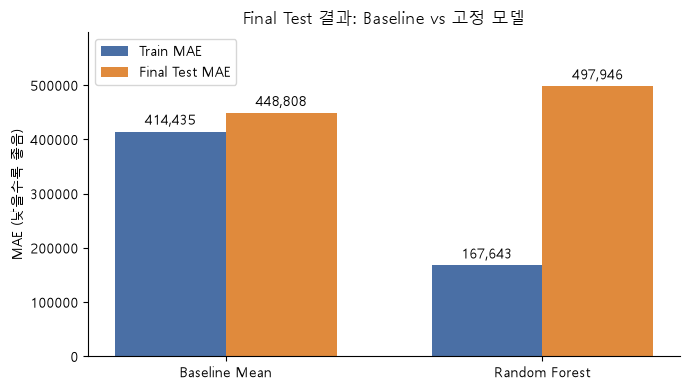


[결과 읽기]
- Baseline Test MAE: 448,808 / Random Forest Test MAE: 497,946
- Baseline 대비 MAE 개선율: -10.9%  (음수면 Baseline보다 나쁨)
- Test R2: -0.219  (0보다 작으면 평균 예측보다 나쁨)
※ 결과가 기대와 달라도 다른 후보로 교체하지 않습니다.


In [10]:
### STEP 9. Final Test에서는 Baseline과 Frozen Model만 평가합니다

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트 (Windows)
plt.rcParams['axes.unicode_minus'] = False

# (앞 셀에서 만든 PROJECT_ROOT, models, FROZEN_MODEL_NAME,
#  X_train, X_test, y_train, y_test를 그대로 사용합니다)

REPORT_DIR = PROJECT_ROOT / 'reports'
IMAGE_DIR = PROJECT_ROOT / 'chapter09' / 'images'
REPORT_DIR.mkdir(exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# 1) 평가 대상은 정확히 2개: Baseline과 STEP 8에서 고정한 모델
final_models = {
    'Baseline Mean': ('baseline', clone(models['Baseline Mean'])),
    FROZEN_MODEL_NAME: ('selected_by_train_cv', clone(models[FROZEN_MODEL_NAME])),
}
print('Final Test 평가 대상:', list(final_models))

# 2) Train 전체로 학습(fit) -> Final Test에는 예측(predict)만
rows = []
for name, (role, pipe) in final_models.items():
    pipe.fit(X_train, y_train)                     # 전처리도 Train에서만 fit
    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)
    rows.append({
        '모델': name,
        'selection_role': role,
        'train_MAE': mean_absolute_error(y_train, train_pred),
        'test_MAE': mean_absolute_error(y_test, test_pred),
        'test_RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'test_R2': r2_score(y_test, test_pred),
    })
model_comparison = pd.DataFrame(rows)

# 3) Baseline 대비 MAE 개선율 (+면 Baseline보다 좋음, -면 나쁨)
baseline_test_mae = model_comparison.loc[model_comparison['selection_role'] == 'baseline', 'test_MAE'].iloc[0]
model_comparison['MAE_improvement_vs_baseline_pct'] = (
    (baseline_test_mae - model_comparison['test_MAE']) / baseline_test_mae * 100
)

# 4) 보기 좋게 반올림 + 표시 + 저장
model_comparison[['train_MAE', 'test_MAE', 'test_RMSE']] = model_comparison[['train_MAE', 'test_MAE', 'test_RMSE']].round(0)
model_comparison['test_R2'] = model_comparison['test_R2'].round(3)
model_comparison['MAE_improvement_vs_baseline_pct'] = model_comparison['MAE_improvement_vs_baseline_pct'].round(1)
display(model_comparison)
model_comparison.to_csv(REPORT_DIR / 'ch09_regression_model_comparison.csv', index=False, encoding='utf-8-sig')


# 5) Evidence 이미지: Train MAE와 Test MAE 비교
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(model_comparison))
width = 0.35
bars1 = ax.bar(x - width / 2, model_comparison['train_MAE'], width, color='#4a6fa5', label='Train MAE')
bars2 = ax.bar(x + width / 2, model_comparison['test_MAE'], width, color='#e08a3c', label='Final Test MAE')
ax.bar_label(bars1, fmt='{:,.0f}', padding=3)
ax.bar_label(bars2, fmt='{:,.0f}', padding=3)
ax.set_xticks(x)
ax.set_xticklabels(model_comparison['모델'])
ax.set_ylabel('MAE (낮을수록 좋음)')
ax.set_title('Final Test 결과: Baseline vs 고정 모델')
ax.set_ylim(0, max(model_comparison['train_MAE'].max(), model_comparison['test_MAE'].max()) * 1.2)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'step06_final_metrics.png', dpi=150)
plt.show()


# 6) 결과 읽기
frozen = model_comparison[model_comparison['selection_role'] == 'selected_by_train_cv'].iloc[0]
print('\n[결과 읽기]')
print(f"- Baseline Test MAE: {baseline_test_mae:,.0f} / {FROZEN_MODEL_NAME} Test MAE: {frozen['test_MAE']:,.0f}")
print(f"- Baseline 대비 MAE 개선율: {frozen['MAE_improvement_vs_baseline_pct']}%  (음수면 Baseline보다 나쁨)")
print(f"- Test R2: {frozen['test_R2']}  (0보다 작으면 평균 예측보다 나쁨)")
print('※ 결과가 기대와 달라도 다른 후보로 교체하지 않습니다.')

## STEP 9. Final Test 결과 요약과 해석

### 결과 요약
Final Test(2026-06-11 ~ 2026-09-10, 61건)에서 평가한 모델은 정확히 두 개다. STEP 8에서 Final Test 전에 고정한 Random Forest는 **Baseline(평균 예측)보다 나은 점이 없었다.**

| 모델 | selection role | Train MAE | Test MAE | Test RMSE | Test R² | Baseline 대비 MAE 개선율 |
|---|---|---|---|---|---|---|
| Baseline Mean | baseline | 414,435 | 448,808 | 526,649 | -0.002 | 0.0% |
| Frozen Selected Model (Random Forest) | selected_by_train_cv | 167,643 | 497,946 | 580,811 | -0.219 | **-10.9%** |

- Evidence: `reports/ch09_regression_model_comparison.csv`, `chapter09/images/step06_final_metrics.png`

### 지표 비교 (Random Forest가 Baseline보다 얼마나 나쁜가)
| 지표 | 읽는 법 | Baseline | Random Forest | 차이 | 판정 |
|---|---|---|---|---|---|
| Test MAE | 평균 오차, 낮을수록 좋음 | 448,808 | 497,946 | +49,138 (약 11% 더 틀림) | Baseline 우세 |
| Test RMSE | 큰 오차에 더 민감한 오차, 낮을수록 좋음 | 526,649 | 580,811 | +54,162 (약 10% 더 틀림) | Baseline 우세 |
| Test R² | 평균 예측 대비 설명력, 0보다 커야 의미 있음 | -0.002 | -0.219 | -0.217 | Baseline 우세 (RF는 평균보다 나쁨) |
| Train → Test MAE 증가 | 새 데이터에서 얼마나 무너지는가 | 414,435 → 448,808 (+8%) | 167,643 → 497,946 (**약 3배**) | | Baseline 안정적 |

**세 지표(MAE, RMSE, R²) 모두 Baseline이 앞선다.** 지표에 따라 결론이 갈리지 않는다.

### 주요 시사점과 해석
1. **복잡한 모델이 추가 가치를 만들지 못했다.**
   Random Forest는 평균 예측보다 오차가 약 11% 크고, R²도 음수다. 처음 던진 질문("복잡하면 평균 예측보다 우수한가?")의 답은 이번 데이터에서 **아니오**다.

2. **Train CV 결과가 Final Test에서도 그대로 재현됐다.**
   Train 교차검증에서 Random Forest는 Baseline보다 약 11% 나빴고(469,067 대 420,959), Final Test에서도 약 11% 나쁘다(-10.9%). 결과가 일관되어서 우연한 결과라고 보기 어렵다.

3. **과적합(overfitting) 신호가 뚜렷하다.**
   Random Forest의 Train MAE는 167,643인데 Test MAE는 497,946으로 약 3배 뛴다. 학습 데이터의 우연한 패턴을 외웠지만, 처음 보는 미래 기간에는 통하지 않았다. Baseline은 Train과 Test 차이가 작다(+8%).
   Train 점수만 봤다면 Random Forest가 좋아 보였을 것이다. **Final Test를 분리한 이유가 여기서 드러난다.**

4. **원인은 feature가 약하기 때문이다.**
   사용한 feature(주문 월, 요일, 결제수단, 나이, 성별, 도시)는 주문 금액과 거의 관계가 없다(상관계수 -0.03~0.05 수준). 금액을 결정하는 수량과 단가는 예측 시점에 알 수 없어 누수 방지를 위해 제외했다.
   누수를 막으면 성능이 낮아지는 것이 정상이다. 이 결과는 오류가 아니라 **정직한 결과**다.

5. **이 결과로 모델을 바꾸지 않는다.**
   Final Test에서 성능이 낮다고 Linear Regression 등으로 교체하면 Final Test가 모델 선택에 참여하게 되어 누수가 된다. 선택은 STEP 8에서 끝났고 그대로 유지한다.

### 결론
- **"현재 데이터와 feature로는 모델 사용 보류"**가 이번 분석의 결론이다.
- 실제 금액 예측에는 평균 예측(Baseline)이 더 낫다.
- 낮은 성능과 음수 R²도 숨기지 않고 그대로 보고한다.

### 한계와 개선 방향
- **한계**: Final Test는 61건, 약 3개월치 하나의 기간이다. 표본이 적어서 수치는 오차가 클 수 있다. 다만 Train CV와 방향이 같아서 결론은 뒷받침된다.
- **개선 방향**: 예측 시점에 알 수 있으면서 금액과 관계가 있는 정보(예: 고객의 과거 구매 이력)가 있는지 확인한다.
- **주의**: 추가 실험을 하려면 새로운 검증 설계 또는 새로운 미래 평가 구간이 필요하다. 지금의 Final Test를 다시 쓰면 안 된다.

# STEP 10. MAE, RMSE, R²를 함께 해석합니다
## Final Test 해석

### 결과 관찰
- **MAE**: Baseline 448,808 / Random Forest 497,946 → 평균 약 45만~50만 틀린다. (Final Test 평균 주문 금액 약 83만의 절반 이상)
- **RMSE**: Baseline 526,649 / Random Forest 580,811 → MAE의 약 1.17배로, 일부 큰 오차가 평가를 크게 끌어올리지는 않는다.
- **R²**: Baseline -0.002 / Random Forest -0.219 → Random Forest는 평균 예측보다 못하다. 음수라는 이유만으로 코드 오류로 보지 않는다.
- **Baseline 대비 개선율**: MAE 기준 **-10.9%** (Baseline보다 나쁨)

### 나의 해석과 판단
- 세 지표가 모두 같은 방향이며, Random Forest는 평균 예측보다 나은 점이 없다.
- Train MAE(167,643)보다 Test MAE(497,946)가 약 3배 커서 **과적합**이다.
- Train CV 결과(약 11% 나쁨)가 Final Test에서도 같아서, 원인은 feature의 예측력이 약한 것으로 판단한다.
- 판단: **현재 데이터로는 모델 사용 보류.** 다른 후보로 교체하지 않는다.

### 업무·분석적 의미
- 이 모델을 쓰면 평균 금액을 쓰는 것보다 오히려 더 틀려서 도입할 이유가 없다.
- 주문 금액은 수량과 단가에 달려 있는데 주문 전에는 알 수 없으므로, 주문 시점 정보만으로는 맞히기 어렵다.
- 누수를 막은 정직한 결과이고, "예측이 어려운 문제"라는 것 자체가 결론이다.

### 현재 한계
- Final Test가 61건, 약 3개월이라 표본이 작다.
- Train 기간에 7~8월이 없어 계절 정보를 학습하지 못했다.
- 사용한 feature가 6개뿐이며, 예측 시점에 알 수 있는 다른 정보(예: 고객의 과거 구매 이력)는 확인하지 않았다.
- 추가 실험은 새로운 검증 설계 또는 새로운 미래 평가 구간이 필요하다.

In [11]:
### step 11

import pandas as pd

# (STEP 9 셀에서 학습을 끝낸 final_models, FROZEN_MODEL_NAME과
#  test_data, X_test, y_test, PROJECT_ROOT를 그대로 사용합니다)
# ※ 여기서는 새로 학습하지 않고, 이미 고정한 모델의 예측 결과만 진단합니다.

REPORT_DIR = PROJECT_ROOT / 'reports'
REPORT_DIR.mkdir(exist_ok=True)

# 1) 고정한 모델과 Baseline의 Final Test 예측값
frozen_pipe = final_models[FROZEN_MODEL_NAME][1]
baseline_pipe = final_models['Baseline Mean'][1]
pred_frozen = frozen_pipe.predict(X_test)
pred_baseline = baseline_pipe.predict(X_test)

# 2) 진단 표 만들기: residual = 실제 - 예측
diag = test_data[['order_id', 'order_date']].copy()
diag = pd.concat([diag, X_test], axis=1)
diag['actual_order_total'] = y_test.values
diag['predicted_order_total'] = pred_frozen.round(0)
diag['residual'] = (diag['actual_order_total'] - diag['predicted_order_total']).round(0)
diag['abs_error'] = diag['residual'].abs()
diag['baseline_abs_error'] = (y_test.values - pred_baseline).round(0)
diag['baseline_abs_error'] = diag['baseline_abs_error'].abs()

# 3) 내부 진단 파일 저장 (order_id가 있으므로 공개하지 않음)
diag.to_csv(REPORT_DIR / 'ch09_regression_predictions_internal.csv', index=False, encoding='utf-8-sig')
print('저장(내부용): reports/ch09_regression_predictions_internal.csv')

# 4) 전체 오차 요약
print('\n[전체 요약]')
print('Final Test 주문 수:', len(diag))
print('평균 절대 오차(MAE):', round(diag['abs_error'].mean()))
print('실제보다 낮게 예측(residual > 0):', (diag['residual'] > 0).sum(), '건')
print('실제보다 높게 예측(residual < 0):', (diag['residual'] < 0).sum(), '건')

# 5) 실제 금액 구간별 평균 오차 (어떤 주문에서 크게 틀리는지)
diag['금액 구간'] = pd.qcut(diag['actual_order_total'], 4, labels=['하위 25%', '중하위', '중상위', '상위 25%'])
by_range = diag.groupby('금액 구간', observed=True).agg(
    주문수=('abs_error', 'size'),
    실제_평균금액=('actual_order_total', 'mean'),
    예측_평균금액=('predicted_order_total', 'mean'),
    평균_절대오차=('abs_error', 'mean'),
    평균_잔차=('residual', 'mean'),
).round(0)
print('\n[실제 금액 구간별 오차]')
display(by_range)

# 6) 큰 오차 상위 5건 (이 중 대표 사례 2~3개를 고름)
cols = ['order_id', 'order_month_num', 'order_dayofweek', 'age', 'payment_method', 'gender', 'city',
        'actual_order_total', 'predicted_order_total', 'residual', 'abs_error', 'baseline_abs_error']
top_errors = diag.sort_values('abs_error', ascending=False).head(5)[cols]
print('[큰 오차 상위 5건]  (residual > 0: 실제보다 낮게 예측 / < 0: 실제보다 높게 예측)')
display(top_errors)

저장(내부용): reports/ch09_regression_predictions_internal.csv

[전체 요약]
Final Test 주문 수: 61
평균 절대 오차(MAE): 497946
실제보다 낮게 예측(residual > 0): 29 건
실제보다 높게 예측(residual < 0): 32 건

[실제 금액 구간별 오차]


,주문수,실제_평균금액,예측_평균금액,평균_절대오차,평균_잔차
금액 구간,,,,,
하위 25%,16,201812.0,870524.0,668711.0,-668711.0
중하위,15,593133.0,806865.0,232914.0,-213731.0
중상위,15,1021200.0,808317.0,280131.0,212883.0
상위 25%,15,1554800.0,756155.0,798645.0,798645.0


[큰 오차 상위 5건]  (residual > 0: 실제보다 낮게 예측 / < 0: 실제보다 높게 예측)


,order_id,order_month_num,order_dayofweek,age,payment_method,gender,city,actual_order_total,predicted_order_total,residual,abs_error,baseline_abs_error
290,51,8,1,32,kakao_pay,F,서울,1877000,458780.0,1418220.0,1418220.0,1019912.0
288,73,8,0,47,bank_transfer,F,고양,72000,1138610.0,-1066610.0,1066610.0,785088.0
265,96,7,1,32,kakao_pay,F,성남,1690000,650860.0,1039140.0,1039140.0,832912.0
279,145,7,3,42,kakao_pay,M,고양,1863000,841890.0,1021110.0,1021110.0,1005912.0
291,21,8,5,59,bank_transfer,M,성남,1767000,797700.0,969300.0,969300.0,909912.0


### STEP 11은 무엇을 하고, 왜 하는가?
- **하는 일**: 모델이 가장 크게 틀린 주문 2~3건을 골라서, 실제 금액과 예측 금액이 얼마나 다른지 하나씩 들여다본다.
- **이유**: MAE 같은 평균 점수만으로는 "어떤 주문에서, 왜 틀리는지"를 알 수 없다. 평균 점수가 나쁜 이유를 개별 사례로 확인하는 것이다.
- **비유**: 시험 평균이 낮게 나왔을 때 점수만 보지 않고, 가장 크게 틀린 문제를 골라서 어떤 유형에서 약한지 확인하는 것과 같다. 예를 들어 "300만 원짜리 주문을 80만 원으로 예측했다"면, 고액 주문을 못 맞히는지 살펴본다.
- **주의**: "관찰"(고액 주문에서 오차가 컸다)과 "가설"(feature가 고액 주문의 특성을 설명하지 못할 수 있다)을 구분해서 쓴다. 데이터가 직접 보여 주지 않는 원인은 사실처럼 단정하지 않는다.
- **산출물**: 주문별 실제값, 예측값, 오차를 담은 내부 진단 파일(`order_id` 포함이라 공개 보고서와 구분)과 대표 사례 2~3개의 기록이다.

### STEP 11 시사점 (쉽게 정리)

1. **평균 점수만으로는 "왜 틀리는지" 알 수 없다.**
   MAE와 RMSE는 전체 평균이라서, 어떤 주문에서 크게 틀리는지는 개별 사례를 봐야 보인다.

2. **틀리는 패턴을 찾으면 개선 방향이 보인다.**
   예를 들어 고액 주문만 유독 크게 틀린다면, 고액 주문의 특성을 설명하는 feature가 부족하다는 단서가 된다. 이 단서로 "어떤 정보가 더 필요한지" 생각할 수 있다.

3. **관찰과 가설을 구분해서 써야 한다.**
   - 관찰(데이터가 보여 주는 사실): "300만 원 주문을 80만 원으로 예측해 오차가 컸다."
   - 가설(확인이 필요한 추측): "현재 feature가 고액 주문의 특성을 설명하지 못했을 수 있다."
   - 데이터가 직접 보여 주지 않는 원인은 사실처럼 단정하지 않는다.

4. **이 단계는 모델을 고치는 단계가 아니라 이해하는 단계다.**
   큰 오차 사례를 봤다고 모델을 바꾸거나 Final Test로 다시 튜닝하지 않는다. 사례는 "다음 분석에서 무엇을 확인할지"를 정리하는 데 쓴다.

5. **개인정보와 내부 자료는 구분한다.**
   `order_id`가 들어 있는 진단 파일은 내부용이고, 공개 보고서에는 `order_id` 없이 요약만 담는다.

## STEP 11. 대표 오차 사례 진단

- 진단 파일(내부용): `reports/ch09_regression_predictions_internal.csv` (order_id 포함, 공개하지 않음)
- residual = 실제값 − 예측값 (residual > 0: 실제보다 낮게 예측 / residual < 0: 실제보다 높게 예측)

### 전체 관찰
- Final Test 61건 중 실제보다 낮게 예측한 주문이 29건, 높게 예측한 주문이 32건으로 한쪽으로 치우치지 않았다.
- 실제 금액 구간별로 보면 양쪽 끝에서 오차가 컸다.

| 실제 금액 구간 | 주문 수 | 실제 평균 | 예측 평균 | 평균 절대 오차 |
|---|---|---|---|---|
| 하위 25% | 16 | 약 20만 | 약 87만 | 약 67만 |
| 중하위 | 15 | 약 59만 | 약 81만 | 약 23만 |
| 중상위 | 15 | 약 102만 | 약 81만 | 약 28만 |
| 상위 25% | 15 | 약 155만 | 약 76만 | 약 80만 |

- 실제 금액이 20만이든 155만이든 예측 평균은 약 76만~87만에 머물러 있다. 모델이 주문 금액을 구분하지 못하고 대부분 평균 근처로 예측하고 있다.
- 큰 오차 상위 5건 중 4건은 고액 주문(약 169만~188만)을 낮게 예측한 경우이고, 1건은 저액 주문(약 7만)을 높게 예측한 경우이다.

### 사례 1 (고액 주문을 낮게 예측)
- 실제값: 1,877,000
- 예측값: 458,780
- residual: +1,418,220
- absolute error: 1,418,220 (Baseline의 오차 1,019,912보다 약 39.8만 더 큼)
- 관찰: 상위 5건 중 오차가 가장 크다. 고액 주문을 실제의 약 4분의 1로 예측했고, 같은 주문에서 평균 예측(Baseline)보다도 오차가 컸다.
- 가능한 이유 후보(가설): 현재 feature(월, 요일, 결제수단, 나이, 성별, 도시)가 고액 주문의 특성을 설명하지 못할 수 있다. 학습 데이터에서 비슷한 조건의 주문이 우연히 낮은 금액이었을 가능성도 있다.
- 추가 확인 사항: 학습 데이터에서 같은 결제수단과 도시의 주문 금액 분포, 이 주문이 여러 상품을 담은 주문인지(수량과 상품 수)

### 사례 2 (저액 주문을 높게 예측)
- 실제값: 72,000
- 예측값: 1,138,610
- residual: -1,066,610
- absolute error: 1,066,610 (Baseline의 오차 785,088보다 약 28.2만 더 큼)
- 관찰: 실제 금액이 매우 작은 주문인데 평균(약 86만)보다도 높게 예측했다.
- 가능한 이유 후보(가설): 특성으로는 소액 주문을 알아볼 단서가 없어서, 모델이 학습 데이터의 우연한 패턴을 따라갔을 수 있다.
- 추가 확인 사항: 소액 주문(예: 10만 원 이하)의 공통점이 특성에 있는지, 학습 데이터에 소액 주문이 얼마나 있는지

### 사례 3 (고액 주문을 낮게 예측, Baseline과 비슷)
- 실제값: 1,863,000
- 예측값: 841,890
- residual: +1,021,110
- absolute error: 1,021,110 (Baseline의 오차 1,005,912와 비슷함)
- 관찰: 예측값이 평균 근처(약 84만)여서, 이 주문에서는 모델이 사실상 평균 예측과 다르지 않았다.
- 가능한 이유 후보(가설): 이 주문의 조건에서는 모델이 뚜렷한 패턴을 찾지 못하고 평균에 가깝게 예측했을 수 있다.
- 추가 확인 사항: 고액 주문의 상품 구성과 수량(예측 시점에는 알 수 없는 정보이므로 사후 분석용으로만 확인)

### 해석
- **관찰**: 모델은 실제 금액이 매우 크거나 매우 작은 주문에서 크게 틀린다.
- **가설**: 현재 feature가 주문 금액의 크기를 설명하지 못해서 모델이 평균 근처로만 예측하는 것일 수 있다. 이 가설은 데이터로 직접 확인된 원인이 아니므로 단정하지 않는다.
- 이 진단은 모델을 바꾸기 위한 것이 아니라 현재 한계를 이해하기 위한 것이다. Final Test 결과를 보고 모델을 교체하지 않는다.

### STEP 12는 무엇을 위한 작업인가?
- **목적**: 지금까지 한 분석이 규칙을 지켰는지 마지막으로 점검하는 "최종 검수"다.
- **방법**: 6개 항목을 검사해서 각각 PASS 또는 FAIL로 표시한다. (금지된 feature를 쓰지 않았는지, Train이 Test보다 앞선 날짜인지, Baseline과 고정 모델이 Final Test에 들어갔는지, R²를 계산할 만큼 Test 행이 충분한지 등)
- **비유**: 시험을 다 치른 뒤에 "커닝하지 않았는지, 시험 범위를 지켰는지, 답안지를 다 냈는지"를 감독관이 체크리스트로 확인하는 것과 같다.
- **판정 기준**: 모두 PASS여야 분석을 완료로 인정한다. 하나라도 FAIL이면 원인, 수정 내용, 재검증 결과를 기록하고 다시 확인한다.
- **핵심**: 성능이 나쁜 것과는 별개다. 이번처럼 성능이 낮아도 규칙을 잘 지켰다면 모두 PASS이고, 그 결과를 믿을 수 있다는 증거가 된다.

In [12]:
import pandas as pd

# (앞 셀에서 만든 PROJECT_ROOT, feature_columns, train_data, test_data, y_test,
#  cv_summary, model_comparison, FROZEN_MODEL_NAME을 그대로 사용합니다)

REPORT_DIR = PROJECT_ROOT / 'reports'
REPORT_DIR.mkdir(exist_ok=True)

# 1) 사용하면 안 되는 feature 목록 (STEP 2에서 제외한 컬럼들)
forbidden_features = [
    'order_total', 'line_total', 'quantity', 'total_quantity', 'item_count',
    'unit_price', 'avg_unit_price', 'category', 'product_name', 'order_status',
    'order_id', 'order_item_id', 'customer_id', 'product_id', 'order_date',
]

checks = []

# 검사 1) 금지된 feature가 입력에 섞여 있지 않은가
overlap = sorted(set(feature_columns) & set(forbidden_features))
checks.append(('forbidden_feature_overlap', len(overlap), 'PASS' if len(overlap) == 0 else 'FAIL'))

# 검사 2) Train 최대 날짜가 Final Test 최소 날짜보다 확실히 앞서는가
train_max = train_data['order_date'].max().normalize()
test_min = test_data['order_date'].min().normalize()
checks.append(('strict_train_before_test', f'{train_max.date()} < {test_min.date()}',
               'PASS' if train_max < test_min else 'FAIL'))

# 검사 3) 선택한 모델이 Train CV 결과에 있고, Baseline이 아닌가
in_cv = FROZEN_MODEL_NAME in set(cv_summary['모델'])
not_baseline = FROZEN_MODEL_NAME != 'Baseline Mean'
checks.append(('selected_model_exists_in_train_cv', FROZEN_MODEL_NAME,
               'PASS' if (in_cv and not_baseline) else 'FAIL'))

# 검사 4) Final Test 결과에 Baseline이 들어 있는가
final_models_list = set(model_comparison['모델'])
has_baseline = 'Baseline Mean' in final_models_list
checks.append(('final_test_contains_baseline', has_baseline, 'PASS' if has_baseline else 'FAIL'))

# 검사 5) Final Test 결과에 고정한 모델이 들어 있는가
has_frozen = FROZEN_MODEL_NAME in final_models_list
checks.append(('final_test_contains_frozen_selected_model', has_frozen, 'PASS' if has_frozen else 'FAIL'))

# 검사 6) R²를 계산할 만큼 Test 행이 충분한가 (최소 2행 이상)
n_test = len(y_test)
checks.append(('test_rows_for_r2', n_test, 'PASS' if n_test >= 2 else 'FAIL'))

# 2) 결과 표 만들기 + 저장
validation = pd.DataFrame(checks, columns=['check', 'value', 'status'])
display(validation)
validation.to_csv(REPORT_DIR / 'ch09_regression_validation.csv', index=False, encoding='utf-8-sig')


# 3) 최종 판정: 하나라도 FAIL이면 완료로 처리하지 않음
fail_checks = validation[validation['status'] == 'FAIL']['check'].tolist()
if len(fail_checks) == 0:
    print('\n모든 검사 PASS -> Chapter09 모델링을 완료 상태로 처리할 수 있습니다.')
else:
    print('\nFAIL 항목:', fail_checks)
    print('-> 완료로 처리하지 말고 FAIL 원인, 수정 내용, 재검증 결과를 기록하세요.')
assert len(fail_checks) == 0, f'검증 실패: {fail_checks}'

,check,value,status
0,forbidden_feature_overlap,0,PASS
1,strict_train_before_test,2026-06-10 < 2026-06-11,PASS
2,selected_model_exists_in_train_cv,Random Forest,PASS
3,final_test_contains_baseline,True,PASS
4,final_test_contains_frozen_selected_model,True,PASS
5,test_rows_for_r2,61,PASS



모든 검사 PASS -> Chapter09 모델링을 완료 상태로 처리할 수 있습니다.


## STEP 12. 자동 Validation Evidence 결과

### 검증 결과
| check | value | status |
|---|---|---|
| forbidden_feature_overlap | 0 | PASS |
| strict_train_before_test | 2026-06-10 < 2026-06-11 | PASS |
| selected_model_exists_in_train_cv | Random Forest | PASS |
| final_test_contains_baseline | True | PASS |
| final_test_contains_frozen_selected_model | True | PASS |
| test_rows_for_r2 | 61 | PASS |

- Evidence: `reports/ch09_regression_validation.csv`
- **6개 항목이 모두 PASS**이므로 FAIL 원인, 수정 내용, 재검증 기록은 필요하지 않다.

### 시사점
1. **분석 과정이 규칙을 지켰다는 증거가 된다.**
   금지된 feature(정답 재료, 사후 정보, ID)가 입력에 0개 섞였고, Train 마지막 날짜(2026-06-10)가 Final Test 첫 날짜(2026-06-11)보다 앞선다. 데이터 누수 없이 평가했다는 뜻이다.
2. **모델 선택 순서를 지켰다.**
   선택한 Random Forest가 Train CV 결과에 있고 Baseline이 아니며, Final Test에는 Baseline과 고정한 모델만 들어갔다. Final Test가 모델 선택에 참여하지 않았다.
3. **R² 계산에 충분한 표본이 있다.**
   Test가 61행이라 R²를 계산할 수 있다. 다만 표본이 많은 편은 아니어서 수치 해석에는 주의가 필요하다.
4. **성능이 낮은 결과도 믿을 수 있다.**
   Random Forest가 Baseline보다 약 11% 더 틀린 결과는 검증을 통과한 절차에서 나왔다. 코드 오류나 누수 때문이 아니라 feature의 예측력이 약해서 나온 결과라고 판단할 수 있다.
5. **이 검사는 성능이 아니라 절차를 확인한다.**
   모두 PASS라는 것이 모델이 좋다는 뜻은 아니다.

### 결론
- 모든 status가 PASS이므로 **Chapter09 모델링을 완료 상태로 처리한다.**
- 최종 결론은 그대로 **"현재 데이터와 feature로는 모델 사용 보류"**이다.

### STEP 13은 무엇을 하는 단계인가?
- **목적**: 분석에서 나온 파일들을 "누가 봐도 되는지"에 따라 나눠서 정리한다.
- **① 검증 Evidence**: 분석이 규칙을 지켰다는 증거 파일이다. 개별 주문 식별자가 없어 공개할 수 있다.
- **② Internal 진단 파일**: `order_id`처럼 개별 주문을 알 수 있는 식별자가 들어 있어 공개하지 않는다.
- **③ 공개 가능한 요약**: 식별자를 뺀 요약 지표와 표다.
- **비유**: 병원 기록에서 "검사 결과 요약(공개 가능)"과 "환자 이름이 적힌 차트(내부용)"를 나눠 보관하는 것과 같다.
- **핵심**: 모델이 잘 만들어졌는지 확인하는 것(STEP 12)과, 결과를 공개해도 되는지 확인하는 것(STEP 13)은 별개의 검토다.

## Evidence와 공개 범위

### 공개 가능한 Evidence
- 검증 Evidence (분석 과정이 규칙을 지켰다는 증거이며, 개별 주문 식별자가 없다)
  - `reports/ch09_regression_validation.csv`
- 데이터 분할, Feature 점검, CV 비교, 모델 비교, 체크리스트는 별도 CSV 대신 **이 노트북의 표와 마크다운**으로 기록했다.

### Internal로만 유지할 파일
- `reports/ch09_regression_predictions_internal.csv` (`order_id` 포함, GitHub에 올리지 않음)

### Internal로 구분한 이유
- 이 파일에는 `order_id`처럼 **개별 주문을 알아볼 수 있는 식별자**가 들어 있다.
- 오차 진단에는 필요하지만, 공개 결과에는 필요하지 않다.
- 공개용 결과에는 식별자를 제거한 요약 지표만 남긴다.

### 해석과 시사점
1. **파일을 목적에 따라 나눠야 한다.** 같은 분석 결과라도 "검증 증거", "내부 진단", "공개 요약"은 보여 줄 대상이 다르다.
2. **모델 검증과 공개 범위 검토는 별개다.** STEP 12에서 모두 PASS가 나와도, 그 결과를 그대로 공개해도 된다는 뜻은 아니다. 식별자가 들어 있는지 따로 확인해야 한다.
3. **그림이나 표를 공개할 때도 주문 번호가 표시되지 않았는지 확인한다.**
4. **성능이 낮은 결과도 그대로 기록한다.** 낮은 성능이나 음수 R²를 빼면 결과가 왜곡된다.

### 결론
- 검증 Evidence는 식별자 없이 공개 가능한 자료로, `predictions_internal.csv`는 내부 진단용으로만 유지한다.
- 이번 분석의 최종 결론(**"현재 데이터와 feature로는 모델 사용 보류"**)과 낮은 성능은 공개 자료에도 그대로 기록한다.

## 전체 재실행 확인

- 입력 준비 성공 여부: 성공 (`data/raw`의 orders, order_items, customers를 셀 안에서 직접 읽고 관계 검증 5개 항목 PASS)
- 회귀 스크립트 실행 성공 여부: 별도 스크립트 없이 노트북 셀로 구현하여, **커널 재시작 후 전체 실행(Restart and Run All)**으로 대체하여 성공
- Train CV Selected Model: Random Forest (cv_MAE_mean 469,067)
- Final Validation 전체 PASS 여부: 예 (6개 항목 모두 PASS)
- Notebook과 스크립트 결과의 일관성: 스크립트가 없으므로 **재실행 전후 노트북 결과를 비교**했고, Selected Model과 Final Test 결과(Test MAE 497,946, R² -0.219)가 동일했다.

### 참고
- 가이드의 `prepare_ch09_data.py`, `run_regression_analysis.py`는 프로젝트에 없어서 사용하지 않았다.
- 결과가 재현되는 이유는 `random_state=42`로 고정했고 데이터와 분할 기준이 같기 때문이다.

## STEP 15 모델 사용 가능성을 판단하고 제출합니다

### STEP 15는 어떤 단계인가?
- **한 줄 요약**: 지금까지의 모든 결과를 모아서 "이 모델을 실제로 써도 되는가?"에 대한 **최종 결정을 내리고 제출하는 단계**다.
- **선택지는 세 가지**: ① 참고용으로 사용 가능, ② 추가 검증 후 사용 가능, ③ 사용 보류. 그중 하나를 골라 근거와 함께 적는다.
- **비유**: 신입 사원 수습 평가와 같다. 시험 점수(성능), 부정행위 여부(누수 검증), 실수 패턴(오류 사례), 회사가 감당할 수 있는 실수 수준(업무 기준)을 모두 보고 "정식 채용 / 더 지켜보기 / 보류"를 결정한다.
- **하지 말아야 할 것**: 성적이 낮다고 시험 문제를 미리 보거나(정답 재료를 feature에 추가), 성적이 잘 나온 답안만 골라서 내는 것(Final Test에서 잘 나온 모델로 교체, 같은 Final Test 반복 사용)이다. 낮은 성능도 숨기지 않는다.
- **핵심**: 좋은 성능을 만드는 것이 아니라 **결과를 정직하게 보고 합리적으로 판단**하는 것이 목표다. "사용 보류"도 올바른 결론이 될 수 있다.

In [13]:
import pandas as pd

# (STEP 9 셀에서 학습을 끝낸 final_models, FROZEN_MODEL_NAME을 그대로 사용합니다)
trained_model = final_models[FROZEN_MODEL_NAME][1]           # 학습이 끝난 Random Forest Pipeline
trained_baseline = final_models['Baseline Mean'][1]          # 학습이 끝난 Baseline

# 1) 새 주문 3건 (주문 시점에 알 수 있는 정보만 입력)
new_orders = pd.DataFrame({
    'order_month_num': [7, 12, 3],
    'order_dayofweek': [1, 5, 0],                            # 0=월, 1=화, ... 6=일
    'age': [30, 45, 22],
    'payment_method': ['card', 'kakao_pay', 'bank_transfer'],
    'gender': ['F', 'M', 'F'],
    'city': ['서울', '부산', '대구'],
})

# 2) 예측하기 (학습 때와 같은 컬럼 순서로 넣어야 함)
new_orders = new_orders[feature_columns]
new_orders['모델 예측 금액'] = trained_model.predict(new_orders).round(0)
new_orders['평균 예측(Baseline)'] = trained_baseline.predict(new_orders[feature_columns]).round(0)

display(new_orders)
print('※ 이 모델은 Baseline보다 오차가 커서 실제 업무에 쓰지 않습니다. 예측 방법을 보여 주는 예시입니다.')

,order_month_num,order_dayofweek,age,payment_method,gender,city,모델 예측 금액,평균 예측(Baseline)
0,7,1,30,card,F,서울,485830.0,857088.0
1,12,5,45,kakao_pay,M,부산,1076830.0,857088.0
2,3,0,22,bank_transfer,F,대구,907920.0,857088.0


※ 이 모델은 Baseline보다 오차가 커서 실제 업무에 쓰지 않습니다. 예측 방법을 보여 주는 예시입니다.


## 최종 사용 판단

- **현재 데이터로는 사용 보류**

### 판단 근거

1. **Baseline보다 나은 점이 없다.** Final Test에서 고정 모델(Random Forest)은 평균 예측(Baseline)보다 MAE가 약 11% 더 크다(497,946 대 448,808, 개선율 -10.9%). RMSE(580,811 대 526,649)와 R²(-0.219 대 -0.002)도 모두 Baseline이 앞선다.
2. **Train CV에서도 같은 결과였고 불안정했다.** Train 교차검증에서도 두 모델 모두 Baseline보다 오차가 컸고(MAE 평균 469,067, 470,981 대 420,959), Linear Regression은 Fold마다 MAE가 404,880~615,229로 크게 흔들렸다(표준편차 74,273). 모의고사와 정식 시험의 결과가 일치해서 우연이 아니라 feature의 예측력이 약한 것으로 판단한다.
3. **평가 절차는 신뢰할 수 있다.** 누수 검증(금지 feature 0개)과 시간 분할 검증(Train 최대 날짜 2026-06-10 < Final Test 최소 날짜 2026-06-11)을 통과했고, 자동 Validation 6개 항목이 모두 PASS였다. 모델 선택은 Final Test 전에 고정했다. 그래서 낮은 성능은 코드나 절차의 오류가 아니라 **현재 정보로는 금액을 맞히기 어렵다는 결과**로 해석한다.
4. **과적합이 확인된다.** Random Forest의 Train MAE(167,643)가 Final Test MAE(497,946)의 3분의 1 수준이다. 학습 데이터의 우연한 패턴을 외웠지만 처음 보는 기간에는 통하지 않았다.
5. **대표 오류 패턴**: 모델이 대부분의 주문을 평균 근처(약 75만~87만)로 예측해서, 실제 금액이 아주 작거나(하위 25%) 아주 큰(상위 25%) 주문에서 오차가 컸다. (내부 진단 결과이며 `order_id`가 포함되어 공개하지 않는다.)

### 업무적 위험
- 평균 오차가 약 50만인데 Final Test 기간의 평균 주문 금액은 약 83만이다. 오차가 평균 금액의 **약 60%**로, 이 모델의 예측값을 금액 산정, 재고, 매출 예측 등에 쓰면 오히려 잘못된 판단을 유도할 수 있다.
- Baseline(평균 예측)조차 평균 금액의 약 54%를 틀리므로, 이 문제는 **현재 정보만으로는 어느 방법을 써도 감당할 만한 오차 수준이 아니다.**
- 예측값이 주문마다 다르게 나오기 때문에 그럴듯해 보이지만 실제로는 평균보다 못하다는 점을 모르고 쓰는 위험이 있다.

### 현재 데이터의 한계
- 사용한 feature(주문 월, 요일, 결제수단, 나이, 성별, 도시)가 주문 금액과 거의 관계가 없다(상관계수 -0.03~0.05 수준). 금액을 결정하는 수량과 단가는 예측 시점에 알 수 없어 누수 방지를 위해 제외했다.
- Final Test가 61건, 약 3개월의 한 기간이라 표본이 작다.
- Train 기간(2025-09~2026-06)에 7~8월이 없어 계절 정보를 학습하지 못했다.
- 데이터에 통화 단위 표기가 없어 금액을 원 단위로 가정했다.

### 다음 개선 우선순위
1. 예측 시점에 알 수 있으면서 금액과 관계가 있는 정보가 있는지 찾는다. (예: 고객의 과거 평균 주문 금액, 과거 구매 횟수. 이 데이터에 있는지는 확인하지 않았다.)
2. 더 긴 기간의 데이터를 확보해서 계절과 표본 부족 문제를 줄인다.
3. 새로운 feature로 다시 실험할 때는 **새로운 검증 설계 또는 새로운 미래 평가 구간**을 사용한다. 지금의 Final Test를 다시 선택 도구로 쓰지 않는다.

## 예측 결과 비교: 모델 예측 vs 평균 예측(Baseline)

### 예시 예측 결과 (새 주문 3건)
| 월 | 요일 | 나이 | 결제수단 | 성별 | 도시 | 모델 예측(Random Forest) | 평균 예측(Baseline) |
|---|---|---|---|---|---|---|---|
| 7 | 화 | 30 | card | F | 서울 | 485,830 | 857,088 |
| 12 | 토 | 45 | kakao_pay | M | 부산 | 1,076,830 | 857,088 |
| 3 | 월 | 22 | bank_transfer | F | 대구 | 907,920 | 857,088 |

### 두 예측의 차이
| 구분 | 모델 예측 | 평균 예측(Baseline) |
|---|---|---|
| 하는 일 | 주문 조건(월, 요일, 나이 등)에 따라 주문마다 다른 값을 낸다 | 모든 주문에 같은 값(약 85.7만)을 낸다 |
| 회귀 모델의 목적 | 조건이 달라지면 결과가 달라지는 패턴을 찾는 것 | 패턴을 찾지 않는다 |
| 이번 실제 성능 (Final Test MAE) | 497,946 (더 나쁨) | 448,808 (더 나음) |

### 해석과 의미
- **개념적 의미**: 회귀 모델을 쓰는 이유는 주문마다 금액이 다를 때 "어떤 주문이 클지 작을지"를 구분하기 위해서다. 그래서 주문마다 다른 값을 내는 모델 예측이 의미상 더 크다.
- **이번 결과**: 모델이 주문마다 다른 값을 냈지만, 그 차이가 실제 금액과 맞지 않았다. 구분은 했으나 **틀린 구분**이라서 오히려 평균 예측보다 나쁜 결과가 되었다.
- **Baseline의 역할**: 모델이 Baseline보다 낫다는 것은 "구분한 것이 실제로 도움이 됐다"는 증거이다. 이번에는 그 증거가 없었다.
- 예측값이 주문마다 다르게 나오면 그럴듯해 보이지만, **Baseline과 나란히 비교하지 않으면 쓸 만하다고 착각할 수 있다.**

### 결론
- 모델 예측은 "패턴을 찾으려는 시도"로서 의미가 있지만, 이번 데이터에서는 그 시도가 성공하지 못했다.
- 실제로 쓸 예측은 평균 예측이 더 낫다. 최종 판단은 **"현재 데이터로는 모델 사용 보류"**이다.
- 이 예시 예측은 예측 방법을 보여 주기 위한 것이며, 업무에 사용하지 않는다.

## LLM 활용 기록

### 사용 목적
Feature Leakage 검토, 전처리와 회귀 코드 초안, 지표 해석 검토, 개념 학습

### 사용한 프롬프트 요약
- Target은 order_total, Target 계산 재료 제외, ID와 사후 정보 제외
- 시간 순서 분할, Train TimeSeriesSplit, Final Test 전 모델 고정, Baseline 비교

### LLM 제안 중 수정한 내용
- feature 제외 근거를 상관계수가 아니라 "예측 시점에 알 수 있는가"로 바꿨다.
- 연-월 형태의 order_month를 월 숫자(1~12)로 바꿨다.
- processed 폴더의 *_clean.csv가 다른 장(5장)용 데이터임을 확인하고, 공통 data/raw를 입력으로 썼다.
- 가이드의 scripts 파일이 없어서 단계별 셀로 구현하고 Restart and Run All로 대체했다.

### 수정 이유
누수 방지, 데이터 출처 일치, 재현성 확보

### 최종 판단은 누가 했는가
분석자인 내가 Evidence를 확인한 뒤 결정함

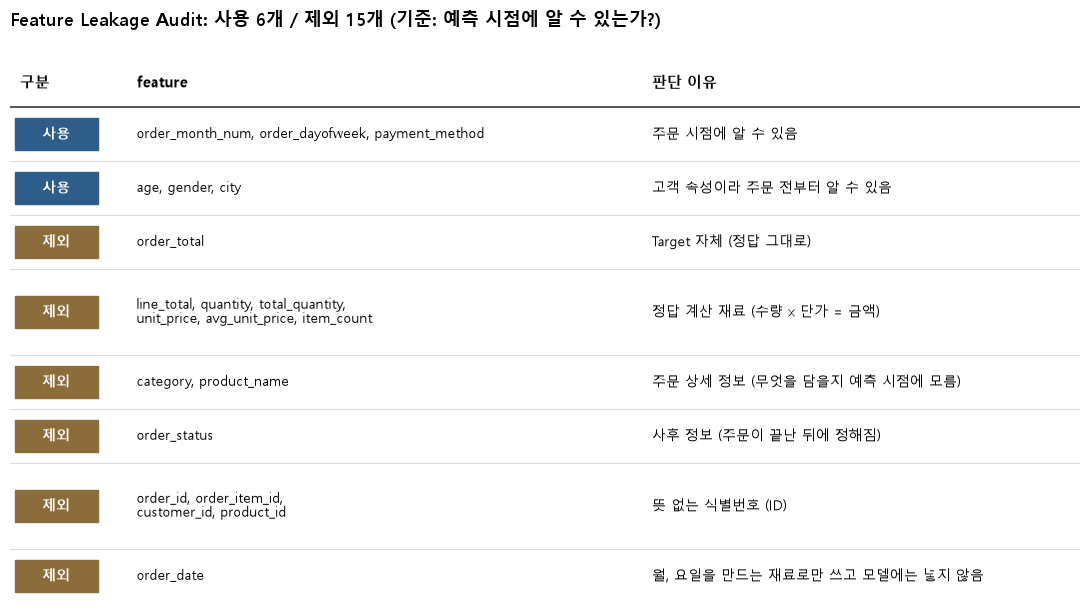

저장 완료: chapter09/images/step02_leakage.png


In [14]:
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']
plt.rcParams['axes.unicode_minus'] = False

# 0) 저장 위치 (노트북이 chapter09 또는 notebooks 폴더에 있어도 동작)
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name in ['notebooks', 'chapter09'] else CURRENT_DIR
IMAGE_DIR = PROJECT_ROOT / 'chapter09' / 'images'
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# 1) Feature Leakage Audit 결과 (STEP 2 표를 그림으로)
rows = [
    ('사용', 'order_month_num, order_dayofweek, payment_method', '주문 시점에 알 수 있음'),
    ('사용', 'age, gender, city', '고객 속성이라 주문 전부터 알 수 있음'),
    ('제외', 'order_total', 'Target 자체 (정답 그대로)'),
    ('제외', 'line_total, quantity, total_quantity,\nunit_price, avg_unit_price, item_count', '정답 계산 재료 (수량 x 단가 = 금액)'),
    ('제외', 'category, product_name', '주문 상세 정보 (무엇을 담을지 예측 시점에 모름)'),
    ('제외', 'order_status', '사후 정보 (주문이 끝난 뒤에 정해짐)'),
    ('제외', 'order_id, order_item_id,\ncustomer_id, product_id', '뜻 없는 식별번호 (ID)'),
    ('제외', 'order_date', '월, 요일을 만드는 재료로만 쓰고 모델에는 넣지 않음'),
]
row_heights = [1, 1, 1, 1.6, 1, 1, 1.6, 1]
color_use, color_drop = '#2f5d8a', '#8a6d3b'

# 2) 그림 그리기
fig, ax = plt.subplots(figsize=(11, 6.2))
ax.set_xlim(0, 11)
total_h = sum(row_heights) + 1.3
ax.set_ylim(0, total_h)
ax.axis('off')

y = total_h - 0.9
ax.text(0.1, y, '구분', fontsize=11, fontweight='bold', va='center')
ax.text(1.3, y, 'feature', fontsize=11, fontweight='bold', va='center')
ax.text(6.6, y, '판단 이유', fontsize=11, fontweight='bold', va='center')
ax.plot([0, 11], [y - 0.45, y - 0.45], color='#333', lw=1.2)
y -= 0.45

for (kind, feats, reason), h in zip(rows, row_heights):
    y_mid = y - h / 2
    color = color_use if kind == '사용' else color_drop
    ax.add_patch(plt.Rectangle((0.05, y_mid - 0.3), 0.85, 0.6, color=color, zorder=2))
    ax.text(0.475, y_mid, kind, color='white', fontsize=10, fontweight='bold', ha='center', va='center', zorder=3)
    ax.text(1.3, y_mid, feats, fontsize=10, va='center')
    ax.text(6.6, y_mid, reason, fontsize=10, va='center')
    y -= h
    ax.plot([0, 11], [y, y], color='#ddd', lw=0.8)

ax.set_title('Feature Leakage Audit: 사용 6개 / 제외 15개 (기준: 예측 시점에 알 수 있는가?)',
             fontsize=13, fontweight='bold', loc='left')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'step02_leakage.png', dpi=150)
plt.show()
print('저장 완료: chapter09/images/step02_leakage.png')